## Estudio del dengue/chikungunya en México 01/01/2024 hasta 02/09/2024 ##

El **dengue** (al igual que la **chikungunya**) es una enfermedad causada por un virus y se transmite a las personas por la picadura del mosquito portador de la 
enfermedad.

<div> <img src="foto_dengue.png" alt="Drawing" style="width: 250px;"/></div>

Al presentarse principalmente en regiones tropicales y subtropicales, es importante analizar esta enfermedad en México.

El **objetivo principal** de este proyecto es poder determinar, dadas las variables, si el paciente fallecerá.

Entre los **objetivos** secundarios se encuentran:

- Determinar el impacto de otras enfermedades con el virus.
- Determinar zonas de mayor riesgo de transmisión del virus.
- Estudiar la relación del sexo del paciente con el virus.

La base de datos fue obtenida los  Datos Abiertos Dirección General de Epidemiología del gobierno federal de México (https://www.gob.mx/salud/documentos/datos-abiertos-152127), aunque es importante recalcar que esta base se actualiza semanalmente, por lo que para tratar de reproducir exactamente este trabajo será necesario consultar https://github.com/EduardoTF/Ciencia-de-Datos-UAS .

Las funciones y modelos utilizados en este proyecto fueron obtenidos y/o basados en los que se encuentran en el Git Hub https://github.com/isadoji/ciencia-de-datos/tree/master , hecho por la Dra. Isabel Domínguez Jímenez, profesora investigadora de la Facultad de Ciencias Físico-Matemáticas de la Universidad Autónoma de Sinaloa.


## Lectura y presentación de los datos ##

In [1]:
#Base de datos dengue/chikunguya México (01/01/2024 - 02/09/2024) y cátalogos descriptivos

#------------------------------------------------------------------------------
#Librerías

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics
from fitter import Fitter
import multiprocessing
import os
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import recall_score 
from sklearn.metrics import precision_score 
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from time import time
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from collections import Counter
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import RandomOverSampler


#------------------------------------------------------------------------------
#Modelos

from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier


#------------------------------------------------------------------------------
#Base de datos 

dengue_data = pd.read_csv("dengue_abierto.csv")    

#------------------------------------------------------------------------------
#Catálogos

dengue_descr = pd.read_csv("Descriptores_Dengue.csv")
dengue_caso = pd.read_csv("CATALOGO_ESTATUS_CASO.csv")
dengue_PCR = pd.read_csv("CATALOGO_RESULTADO_PCR.csv")
dengue_dict = pd.read_csv("CATALOGO_DICTAMEN.csv")
dengue_tpx = pd.read_csv("CATALOGO_TIPO_PACIENTE.csv")
dengue_munic = pd.read_csv("CATALOGO_MUNICIPIOS.csv")
dengue_entidad = pd.read_csv("CATALOGO_ENTIDAD.csv")
dengue_inst = pd.read_csv("CATALOGO_INSTITUCION.csv")
dengue_si_no = pd.read_csv("CATALOGO_SI_NO.csv")
dengue_sexo = pd.read_csv("CATALOGO_SEXO.csv")

In [2]:
#Base de datos dengue/chikunguya México (01/01/2024 - 02/09/2024)

dengue_data

,FECHA_ACTUALIZACION,ID_REGISTRO,SEXO,EDAD_ANOS,ENTIDAD_RES,MUNICIPIO_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,...,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG,MUNICIPIO_ASIG
0,02/09/2024,849113,2,35,12,29,2,2,12,29,...,2,2,2,2,5.0,1,5,3,12,29
1,02/09/2024,873810,2,55,18,17,2,2,18,17,...,2,2,2,2,5.0,2,5,1,18,17
2,02/09/2024,1081911,2,11,20,67,2,2,20,67,...,2,2,2,2,5.0,2,5,1,20,67
3,02/09/2024,1207499,1,51,17,11,2,2,17,11,...,2,2,2,2,5.0,1,5,1,17,11
4,02/09/2024,1299508,1,5,23,5,2,2,23,5,...,2,2,2,2,5.0,1,5,3,23,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237591,02/09/2024,1564857,2,34,17,18,2,2,17,7,...,2,2,2,2,5.0,1,5,1,17,18
237592,02/09/2024,1564858,1,21,17,7,2,2,17,7,...,2,2,2,2,5.0,1,5,1,17,7
237593,02/09/2024,1564859,2,3,7,40,2,2,7,40,...,2,2,2,2,5.0,1,5,1,7,40
237594,02/09/2024,1564860,1,19,15,82,2,2,15,82,...,2,2,2,2,5.0,1,5,1,15,82


<div class="alert alert-block alert-info">
<b>

La base de de datos cuenta con 28 variables y 237,596 pacientes registrados.

In [3]:
#Tipos de datos de la base de datos

print(dengue_data.dtypes)


FECHA_ACTUALIZACION        object
ID_REGISTRO                 int64
SEXO                        int64
EDAD_ANOS                   int64
ENTIDAD_RES                 int64
MUNICIPIO_RES               int64
HABLA_LENGUA_INDIG          int64
INDIGENA                    int64
ENTIDAD_UM_NOTIF            int64
MUNICIPIO_UM_NOTIF          int64
INSTITUCION_UM_NOTIF        int64
FECHA_SIGN_SINTOMAS        object
TIPO_PACIENTE               int64
HEMORRAGICOS                int64
DIABETES                    int64
HIPERTENSION                int64
ENFERMEDAD_ULC_PEPTICA      int64
ENFERMEDAD_RENAL            int64
INMUNOSUPR                  int64
CIRROSIS_HEPATICA           int64
EMBARAZO                    int64
DEFUNCION                   int64
DICTAMEN                  float64
TOMA_MUESTRA                int64
RESULTADO_PCR               int64
ESTATUS_CASO                int64
ENTIDAD_ASIG                int64
MUNICIPIO_ASIG              int64
dtype: object


In [4]:
#Descripción de los datos

dengue_data.describe()

,ID_REGISTRO,SEXO,EDAD_ANOS,ENTIDAD_RES,MUNICIPIO_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,INSTITUCION_UM_NOTIF,...,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG,MUNICIPIO_ASIG
count,2.375960e+05,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000,...,237596.000000,237596.000000,237596.000000,237596.000000,237591.000000,237596.000000,237596.000000,237596.000000,237596.000000,237596.000000
mean,1.432164e+06,1.454566,28.883024,17.133083,56.398252,1.981485,1.977428,17.123929,52.729381,10.418113,...,1.998721,1.999263,1.987218,1.996444,4.994406,1.494516,4.800178,1.616454,17.417650,59.481035
std,7.599311e+04,0.497932,18.498862,7.098741,85.673926,0.134803,0.148535,7.099216,88.380208,7.908899,...,0.035747,0.027129,0.112334,0.059530,0.115136,0.499971,0.650382,0.807822,8.462982,100.929270
min,8.491130e+05,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.367372e+06,1.000000,14.000000,12.000000,8.000000,2.000000,2.000000,12.000000,7.000000,4.000000,...,2.000000,2.000000,2.000000,2.000000,5.000000,1.000000,5.000000,1.000000,12.000000,8.000000
50%,1.431172e+06,1.000000,26.000000,17.000000,29.000000,2.000000,2.000000,17.000000,31.000000,6.000000,...,2.000000,2.000000,2.000000,2.000000,5.000000,1.000000,5.000000,1.000000,17.000000,29.000000
75%,1.495044e+06,2.000000,41.000000,21.000000,67.000000,2.000000,2.000000,21.000000,67.000000,20.000000,...,2.000000,2.000000,2.000000,2.000000,5.000000,2.000000,5.000000,2.000000,21.000000,67.000000
max,1.564861e+06,2.000000,140.000000,35.000000,570.000000,2.000000,2.000000,32.000000,999.000000,99.000000,...,2.000000,2.000000,2.000000,2.000000,5.000000,2.000000,5.000000,3.000000,99.000000,999.000000


In [5]:
#Busqueda de datos nulos y reemplazo de los mismos
print(dengue_data.isna().sum())
for col in ['DICTAMEN']:
    dengue_data[col]= dengue_data[col].fillna(5) #Se le llena con "No Aplica"
print()
print()
print()
print(dengue_data.isna().sum())

FECHA_ACTUALIZACION       0
ID_REGISTRO               0
SEXO                      0
EDAD_ANOS                 0
ENTIDAD_RES               0
MUNICIPIO_RES             0
HABLA_LENGUA_INDIG        0
INDIGENA                  0
ENTIDAD_UM_NOTIF          0
MUNICIPIO_UM_NOTIF        0
INSTITUCION_UM_NOTIF      0
FECHA_SIGN_SINTOMAS       0
TIPO_PACIENTE             0
HEMORRAGICOS              0
DIABETES                  0
HIPERTENSION              0
ENFERMEDAD_ULC_PEPTICA    0
ENFERMEDAD_RENAL          0
INMUNOSUPR                0
CIRROSIS_HEPATICA         0
EMBARAZO                  0
DEFUNCION                 0
DICTAMEN                  5
TOMA_MUESTRA              0
RESULTADO_PCR             0
ESTATUS_CASO              0
ENTIDAD_ASIG              0
MUNICIPIO_ASIG            0
dtype: int64



FECHA_ACTUALIZACION       0
ID_REGISTRO               0
SEXO                      0
EDAD_ANOS                 0
ENTIDAD_RES               0
MUNICIPIO_RES             0
HABLA_LENGUA_INDIG        0
INDI

In [6]:
#Catálogos descriptivos de la base de datos
print("Descriptores")
dengue_descr = pd.read_csv("Descriptores_Dengue.csv")
dengue_descr


Descriptores


,NO.,NOMBRE DE VARIABLE,DESCRIPCION,FORMATO O FUENTE
0,1,FECHA_ACTUALIZACION,LA BASE DE DATOS SE ACTUALIZA SEMANALMENTE. ES...,"AAAA-MM-DD, 9999-99-99: CUANDO NO HAY REGISTRO"
1,2,ID_REGISTRO,NÚMERO DE INDETIFICADOR DEL CASO,TEXTO
2,3,SEXO,IDENTIFICA EL SEXO DEL PACIENTE,CATÁLOGO: SEXO
3,4,EDAD_ANOS,IDENTIFICA LA EDAD EN AÑOS DEL PACIENTE,NÚMERICA EN AÑOS
4,5,ENTIDAD_RES,IDENTIFICA LA ENTIDAD DE RESIDENCIA DEL PACIENTE,CATÁLOGO: ENTIDADES
5,6,MUNICIPIO_RES,IDENTIFICA EL MUNICIPIO DE RESIDENCIA DEL PACI...,CATÁLOGO: MUNICIPIOS
6,7,HABLA_LENGUA_INDIG,IDENTIFICA SI EL PACIENTE HABLA LENGUA INDIGENA,CATÁLOGO: SI /NO
7,8,INDIGENA,IDENTIFICA SI EL PACIENTE SE AUTOIDENTIFICA CO...,CATÁLOGO: SI /NO
8,9,ENTIDAD_UM_NOTIF,IDENTIFICA LA ENTIDAD DONDE SE ENCUENTRA LA UN...,CATÁLOGO: ENTIDADES
9,10,MUNICIPIO_UM_NOTIF,IDENTIFICA EL MUNICIPIO DONDE SE ENCUENTRA LA ...,CATÁLOGO: MUNICIPIOS


La mayoría de las variables están presentadas de forma categórica, por lo que es importante consultar de su catálogo correspondiente (si le es más facil, se puede descargar el catálogo en csv desde el GitHub del proyecto). De todas las variables, la única que presenta datos continuos es la edad. 

Los catálogos de la base de datos son los siguientes:

In [7]:
print("Estatus del caso")

dengue_caso


Estatus del caso


,CLAVE,DESCRIPCIÓN
0,1,PROBABLE
1,2,CONFIRMADO
2,3,DESCARTADO


In [8]:
print("Resultado del estudio PCR")

dengue_PCR


Resultado del estudio PCR


,CLAVE,DESCRIPCIÓN
0,1,DENV1
1,2,DENV2
2,3,DENV3
3,4,DENV4
4,5,SIN SEROTIPO AISLADO


Como en muchos virus, existen varias cepas o serotipos de dengue. En específico, existen 4 serotipos de dengue y se denominan DENV1, DENV2, DENV3 y DENV4.

<div> <img src="E8cqLkVWYAUVNla.jpg" alt="Drawing" style="width: 500px;"/></div>

In [9]:
print("Dictamen del paciente")

dengue_dict


Dictamen del paciente


,CLAVE,DESCRIPCIÓN
0,1,CONFIRMADO A DENGUE
1,2,CONFIRMADO A CHIKUNGUNYA
2,3,NEGATIVO
3,4,EN ESTUDIO
4,5,NO APLICA


In [10]:
print("Tipo de tratamiento del paciente")

dengue_tpx


Tipo de tratamiento del paciente


,CLAVE,DESCRIPCIÓN
0,1,AMBULATORIO
1,2,HOSPITALIZADO


In [11]:
print("Municipios")

dengue_munic


Municipios


,CLAVE_MUNICIPIO,MUNICIPIO,CLAVE_ENTIDAD
0,1,AGUASCALIENTES,01
1,2,ASIENTOS,01
2,3,CALVILLO,01
3,4,COSÍO,01
4,5,JESÚS MARÍA,01
...,...,...,...
2498,335,OTROS PAISES,OTROS
2499,999,NO ESPECIFICADO,32
2500,997,NO APLICA,97
2501,998,SE IGNORA,98


In [12]:
print("Entidades")

dengue_entidad


Entidades


,CLAVE_ENTIDAD,ENTIDAD_FEDERATIVA,ABREVIATURA
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG


In [13]:
print("Catalogación del si y no")

dengue_si_no


Catalogación del si y no


,CLAVE,DESCRIPCIÓN
0,1,SI
1,2,NO


In [14]:
print("Sexo del paciente")

dengue_sexo

Sexo del paciente


,CLAVE,DESCRIPCIÓN
0,1,MUJER
1,2,HOMBRE


In [15]:
print("Institucion de atención del paciente")

dengue_inst 

Institucion de atención del paciente


,CLAVE,DESCRIPCIÓN
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR
5,6,ISSSTE
6,7,MUNICIPAL
7,8,PEMEX
8,9,PRIVADA
9,10,SEDENA


<div class="alert alert-block alert-info">
<b>

Se puede concluir que la base de datos ofrecida por el gobierno de México se encuentra con una organización y limpieza de los datos excelente. Esta base de datos apenas presenta 5 valores nulos y cada variable se encuentra categorizada de manera sencilla e inequívoca.

## Primera eliminación de variables ##

Para los objetivos de este proyecto, en primeras instancias hay variables que no nos son de utilidad, ya sea porque suelen servir para identificar al paciente, indicar la fecha o el municipio. 

In [16]:
#Primera eliminación de variables

print('Primera eliminación de variables')
dengue_data.drop(columns=['FECHA_ACTUALIZACION','ID_REGISTRO','MUNICIPIO_RES','MUNICIPIO_UM_NOTIF','MUNICIPIO_ASIG', "FECHA_SIGN_SINTOMAS"],inplace=True) 

dengue_data

Primera eliminación de variables


,SEXO,EDAD_ANOS,ENTIDAD_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,...,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG
0,2,35,12,2,2,12,12,1,2,2,...,2,2,2,2,2,5.0,1,5,3,12
1,2,55,18,2,2,18,4,1,2,2,...,2,2,2,2,2,5.0,2,5,1,18
2,2,11,20,2,2,20,20,1,2,2,...,2,2,2,2,2,5.0,2,5,1,20
3,1,51,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
4,1,5,23,2,2,23,4,1,2,2,...,2,2,2,2,2,5.0,1,5,3,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237591,2,34,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
237592,1,21,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
237593,2,3,7,2,2,7,20,2,2,2,...,2,2,2,2,2,5.0,1,5,1,7
237594,1,19,15,2,2,15,20,2,2,2,...,2,2,2,2,2,5.0,1,5,1,15


También es importante descartar los pacientes registrados confirmados negativos a dengue o chikungunya

In [17]:
#Eliminación de datos con pacientes negativos

dengue_data.drop(dengue_data.loc[dengue_data['ESTATUS_CASO'] == 3].index,inplace=True)

dengue_data

,SEXO,EDAD_ANOS,ENTIDAD_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,...,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG
1,2,55,18,2,2,18,4,1,2,2,...,2,2,2,2,2,5.0,2,5,1,18
2,2,11,20,2,2,20,20,1,2,2,...,2,2,2,2,2,5.0,2,5,1,20
3,1,51,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
5,2,3,27,2,2,27,20,1,2,2,...,2,2,2,2,2,5.0,2,5,1,27
6,1,23,20,2,2,20,4,1,2,2,...,2,2,2,2,2,5.0,2,5,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237591,2,34,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
237592,1,21,17,2,2,17,4,1,2,2,...,2,2,2,2,2,5.0,1,5,1,17
237593,2,3,7,2,2,7,20,2,2,2,...,2,2,2,2,2,5.0,1,5,1,7
237594,1,19,15,2,2,15,20,2,2,2,...,2,2,2,2,2,5.0,1,5,1,15


<div class="alert alert-block alert-info">
<b>

Con esto nuestra base de datos pasa a tener 22 variables y a contar con el registro de 188,160 pacientes.

## Exploración de los datos ##

Primero separamos a los pacientes entre los que fallecieron y los que se recuperaron.

In [18]:
#Defunciones por dengue

defun_data = dengue_data[(dengue_data['DEFUNCION'] == 1)]


print(defun_data)

defun_data.describe()


        SEXO  EDAD_ANOS  ENTIDAD_RES  HABLA_LENGUA_INDIG  INDIGENA  \
250        1         32           15                   2         2   
494        2         42           23                   2         2   
570        1         14           12                   2         2   
2268       1         25            4                   2         2   
2861       2         10           12                   2         2   
...      ...        ...          ...                 ...       ...   
229914     1         28           12                   2         2   
230671     2         62           25                   2         2   
230860     2         62           25                   2         2   
232202     1         79           12                   2         2   
234979     2         26           12                   1         1   

        ENTIDAD_UM_NOTIF  INSTITUCION_UM_NOTIF  TIPO_PACIENTE  HEMORRAGICOS  \
250                   15                     6              2             2   
4

,SEXO,EDAD_ANOS,ENTIDAD_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,...,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,...,404.000000,404.000000,404.000000,404.000000,404.0,404.000000,404.000000,404.00000,404.000000,404.000000
mean,1.435644,37.329208,16.750000,1.982673,1.975248,16.801980,12.537129,1.957921,1.950495,1.863861,...,1.970297,1.990099,1.995050,1.962871,1.0,3.064356,1.163366,4.29703,1.700495,17.591584
std,0.496456,25.066127,6.855066,0.130647,0.155562,6.887641,11.076370,0.201019,0.217189,0.343361,...,0.169977,0.099133,0.070272,0.189312,0.0,1.472938,0.370158,1.02857,0.458609,10.604977
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.00000,1.000000,3.000000
25%,1.000000,14.000000,12.000000,2.000000,2.000000,12.000000,4.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.0,1.000000,1.000000,3.00000,1.000000,12.000000
50%,1.000000,32.500000,17.000000,2.000000,2.000000,17.000000,12.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.0,4.000000,1.000000,5.00000,2.000000,17.000000
75%,2.000000,59.000000,20.000000,2.000000,2.000000,20.000000,20.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.0,4.000000,1.000000,5.00000,2.000000,20.000000
max,2.000000,92.000000,32.000000,2.000000,2.000000,31.000000,99.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.0,5.000000,2.000000,5.00000,2.000000,99.000000


In [19]:
#Recuperados por dengue

recup_data = dengue_data[(dengue_data['DEFUNCION'] == 2)]


print(recup_data)

recup_data.describe()


        SEXO  EDAD_ANOS  ENTIDAD_RES  HABLA_LENGUA_INDIG  INDIGENA  \
1          2         55           18                   2         2   
2          2         11           20                   2         2   
3          1         51           17                   2         2   
5          2          3           27                   2         2   
6          1         23           20                   2         2   
...      ...        ...          ...                 ...       ...   
237591     2         34           17                   2         2   
237592     1         21           17                   2         2   
237593     2          3            7                   2         2   
237594     1         19           15                   2         2   
237595     1         40           15                   2         2   

        ENTIDAD_UM_NOTIF  INSTITUCION_UM_NOTIF  TIPO_PACIENTE  HEMORRAGICOS  \
1                     18                     4              1             2   
2

,SEXO,EDAD_ANOS,ENTIDAD_RES,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,...,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO,ENTIDAD_ASIG
count,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,187756.000000,...,187756.000000,187756.000000,187756.000000,187756.000000,187756.0,187756.0,187756.000000,187756.000000,187756.000000,187756.000000
mean,1.459937,28.505710,16.920759,1.981801,1.978035,16.911587,10.285472,1.161124,1.993236,1.978962,...,1.998503,1.999158,1.999537,1.989806,2.0,5.0,1.625115,4.748775,1.251987,17.099283
std,0.498394,18.218697,6.919257,0.133671,0.146569,6.918182,8.084422,0.367646,0.081966,0.143511,...,0.038657,0.028997,0.021521,0.100450,0.0,0.0,0.484095,0.720439,0.434155,7.835208
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,2.0,5.0,1.000000,1.000000,1.000000,1.000000
25%,1.000000,14.000000,12.000000,2.000000,2.000000,12.000000,4.000000,1.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,5.0,1.000000,5.000000,1.000000,12.000000
50%,1.000000,26.000000,17.000000,2.000000,2.000000,17.000000,5.000000,1.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,5.0,2.000000,5.000000,1.000000,17.000000
75%,2.000000,40.000000,20.000000,2.000000,2.000000,20.000000,20.000000,1.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,5.0,2.000000,5.000000,2.000000,20.000000
max,2.000000,140.000000,35.000000,2.000000,2.000000,32.000000,99.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.0,5.0,2.000000,5.000000,2.000000,99.000000


Visualizando los datos de recuperación y defunción por sexo:

<Figure size 200x200 with 0 Axes>

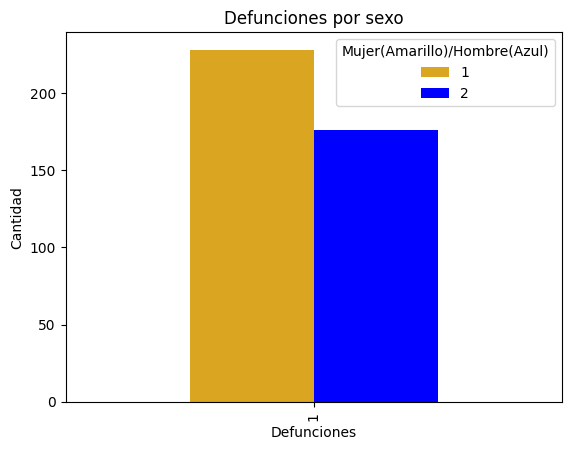

<Figure size 200x200 with 0 Axes>

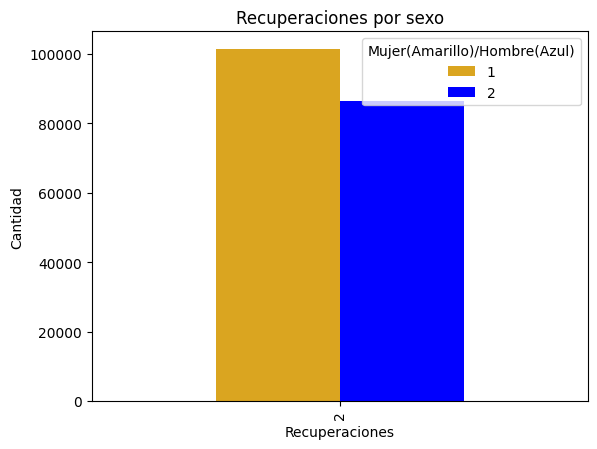

In [20]:
#Separamos los datos a graficar

desired_columns = ['SEXO','DEFUNCION','EDAD_ANOS']

SubData1 = dengue_data[desired_columns] #Obtener Sexo, Defunción y Edad

Defun = SubData1[SubData1['DEFUNCION']==1] #Difuntos
Recup = SubData1[SubData1['DEFUNCION']==2] #Recuperados

#-------------------------------------------------------------------------------------------

#Gráfica de barras de defunciones por sexo
defun_recup = Defun.groupby('DEFUNCION')['SEXO'].value_counts(normalize=False).unstack()
plt.figure(figsize=(2, 2))
defun_recup.plot(kind='bar',stacked=False, color=['goldenrod','blue'])
plt.xlabel('Defunciones')
plt.ylabel('Cantidad')
plt.title('Defunciones por sexo')
plt.legend(title='Mujer(Amarillo)/Hombre(Azul)')
plt.savefig("Defunciones_sexo.png", format="png")
plt.show()

#-------------------------------------------------------------------------------------------

#Gráfica de barras de recuperaciones por sexo
defun_recup = Recup.groupby('DEFUNCION')['SEXO'].value_counts(normalize=False).unstack()
plt.figure(figsize=(2, 2))
defun_recup.plot(kind='bar',stacked=False, color=['goldenrod','blue'])
plt.xlabel('Recuperaciones')
plt.ylabel('Cantidad')
plt.title('Recuperaciones por sexo')
plt.legend(title='Mujer(Amarillo)/Hombre(Azul)')
plt.savefig("Recuperaciones_sexo.png", format="png")
plt.show()

In [21]:
Mujer = dengue_data[dengue_data["SEXO"]==1]
Hombre = dengue_data[dengue_data["SEXO"]==2]

porc_mujer = (len(Mujer)/len(dengue_data))*100
porc_hombre = (len(Hombre)/len(dengue_data))*100

print("Tenemos que el porcentaje de mujeres en los contagiados por dengue/chikungunya es de %.2f" %(porc_mujer),"%,")
print("mientras que el porcentaje de hombres es de %.2f" %(porc_hombre), "%.")


Tenemos que el porcentaje de mujeres en los contagiados por dengue/chikungunya es de 54.01 %,
mientras que el porcentaje de hombres es de 45.99 %.


<div class="alert alert-block alert-info">
<b>

Tenemos que en general se encuentran muchas más personas que se recuperaron del dengue/chikungunya que aquellas que lamentablemente fallecieron. Por esto es que se separan las gráficas de barras entre los pacientes recuperados y los difuntos.

Es importante no infravalorar la letalidad del dengue/chikungunya, pues estos datos pueden estar sesgados por el sesgo del superviviente, puesto que estos datos están hecho para las personas que fueron atendidas en una unidad médica y no cubre aquellas que no buscaron o no tuvieron acceso a atención médica.

También se puede concluir que hay una ligera tendencia a que las mujeres se contagien más que los hombres, aunque se encuentran casi en el mismo porcentaje (54.01 % y 45.99 %, respectivamente.), por lo que es posible que esta no sea una variable determinante para nuestro modelo.

<Figure size 200x200 with 0 Axes>

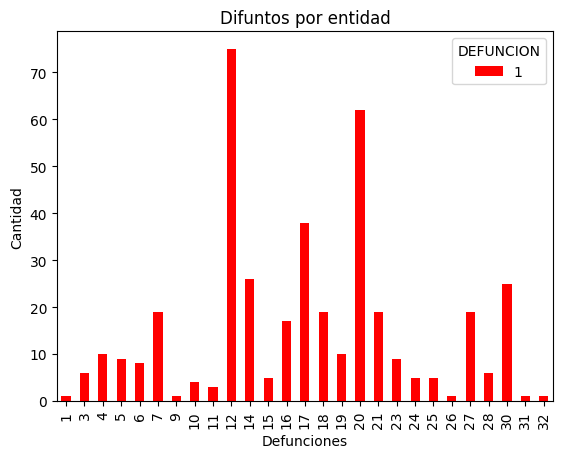

<Figure size 200x200 with 0 Axes>

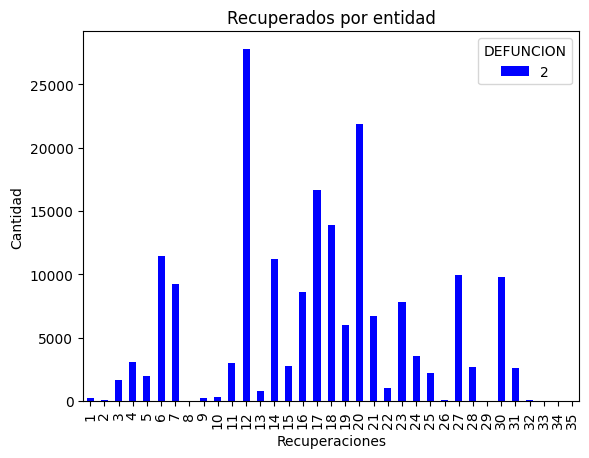

In [22]:
#Separamos los datos para los estados de la república

desired_columns = ['ENTIDAD_RES','DEFUNCION']

SubData2 = dengue_data[desired_columns] #Obtener Entidad y defunción

Defun = SubData2[SubData2['DEFUNCION']==1] #Difuntos
Recup = SubData2[SubData2['DEFUNCION']==2] #Recuperados

#-------------------------------------------------------------------------------------------
#Gráfica de barras de defunciones por estado
defun_est = Defun.groupby('ENTIDAD_RES')['DEFUNCION'].value_counts(normalize=False).unstack()
plt.figure(figsize=(2, 2))
defun_est.plot(kind='bar',stacked=False, color = "red")
plt.xlabel('Defunciones')
plt.ylabel('Cantidad')
plt.title('Difuntos por entidad')
plt.savefig("Defunciones_entidad.png", format="png")
plt.show()

#-------------------------------------------------------------------------------------------
#Gráfica de barras de recuperados por estado
recup_est = Recup.groupby('ENTIDAD_RES')['DEFUNCION'].value_counts(normalize=False).unstack()
plt.figure(figsize=(2, 2))
recup_est.plot(kind='bar',stacked=False, color = "blue")
plt.xlabel('Recuperaciones')
plt.ylabel('Cantidad')
plt.title('Recuperados por entidad')
plt.savefig("Recuperaciones_entidad.png", format="png")
plt.show()


In [23]:
#Conteo de infectados por estados
dengue_data.groupby('ENTIDAD_RES')['ENTIDAD_RES'].count().sort_values(ascending=False)

ENTIDAD_RES
12    27872
20    21911
17    16732
18    13937
6     11493
14    11259
27     9949
30     9849
7      9290
16     8638
23     7815
21     6728
19     5990
24     3575
4      3076
11     3004
15     2805
28     2708
31     2606
25     2218
5      2000
3      1675
22     1044
13      811
10      344
9       269
1       202
2       106
26       94
32       83
8        27
29       25
34       15
35        7
33        3
Name: ENTIDAD_RES, dtype: int64

<div class="alert alert-block alert-info">
<b>

Las entidades de la república mexicana que más casos tienen de dengue/chikungunya (tanto recuperados como difuntos) son <ins>Guerrero</ins> (12) con 27 872, <ins>Oaxaca</ins> (20) con 21 911 y <ins>Morelos</ins> (17) con 16 732.

## Segunda eliminación de variables ##

Ahora se mostrarán las correlaciones entre las variables de la base de datos del dengue/chikungunya:

In [24]:
def corr_matrix(data): #matriz de correlación
    correlation = data.corr()
    plt.figure(figsize=(20, 12))
    sns.heatmap(correlation, annot=True, fmt='.3f', cbar=True, cmap="RdYlGn")
    plt.savefig("Heatmap.png", format="png")
    

La matriz de correlación para las variables de la base de datos del dengue/chikungunya es


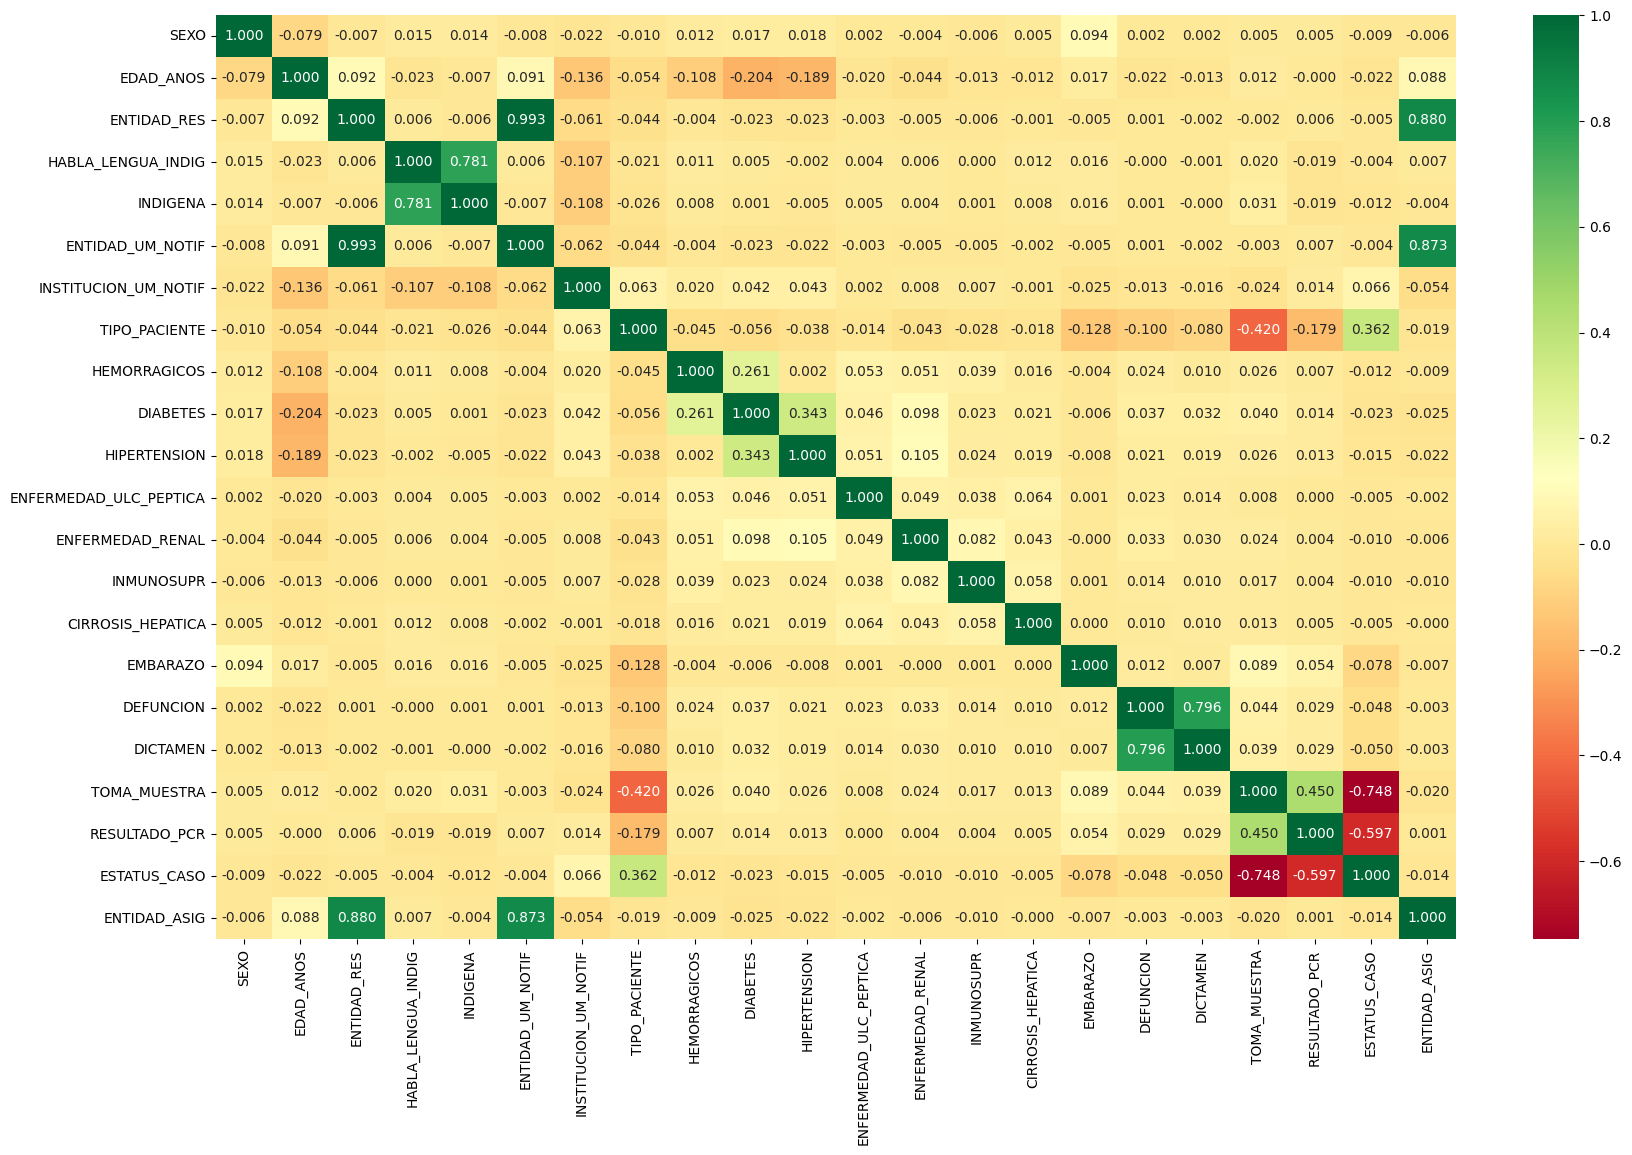

In [25]:
print("La matriz de correlación para las variables de la base de datos del dengue/chikungunya es")
corr_matrix(dengue_data)

In [26]:
print('Segunda eliminación de variables')
dengue_data.drop(columns=['ENTIDAD_UM_NOTIF','ENTIDAD_ASIG','HABLA_LENGUA_INDIG'],inplace=True) 

dengue_data

Segunda eliminación de variables


,SEXO,EDAD_ANOS,ENTIDAD_RES,INDIGENA,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,HIPERTENSION,ENFERMEDAD_ULC_PEPTICA,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO
1,2,55,18,2,4,1,2,2,2,2,2,2,2,2,2,5.0,2,5,1
2,2,11,20,2,20,1,2,2,2,2,2,2,2,2,2,5.0,2,5,1
3,1,51,17,2,4,1,2,2,2,2,2,2,2,2,2,5.0,1,5,1
5,2,3,27,2,20,1,2,2,2,2,2,2,2,2,2,5.0,2,5,1
6,1,23,20,2,4,1,2,2,2,2,2,2,2,2,2,5.0,2,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237591,2,34,17,2,4,1,2,2,2,2,2,2,2,2,2,5.0,1,5,1
237592,1,21,17,2,4,1,2,2,2,2,2,2,2,2,2,5.0,1,5,1
237593,2,3,7,2,20,2,2,2,2,2,2,2,2,2,2,5.0,1,5,1
237594,1,19,15,2,20,2,2,2,2,2,2,2,2,2,2,5.0,1,5,1


<div class="alert alert-block alert-info">
<b>

De esta matriz de correlación se tienen muchas correlaciones que podrían significar que podrían representarse con una sola variable. Por ejemplo, la entidad de residencia, la entidad de la unidad médica y la entidad asignada casi representan el mismo valor; pero estos no parecen tener casi impacto en nuestra variable objetivo de Defunción, por lo que podemos quedarnos solo con la variable de Entidad de Residencia. Otra de este tipo es la de ser indígena y el de hablar una lengua indígena, por lo que se dejará la variable Indígena.

También hay relaciones esperables, como lo son el resultado del PCR, la toma de la muestra y el estatus del caso. 

De entre todas las variables, parece ser que la que tiene más peso con el de Defunción es el de Dictamen, por lo que habrá que tener esta variable más en cuenta.

## Distribuciones ##

Como la única variable continua es la edad de los pacientes, esta es la variable que será estudiada para las distribuciones de probabilidad.

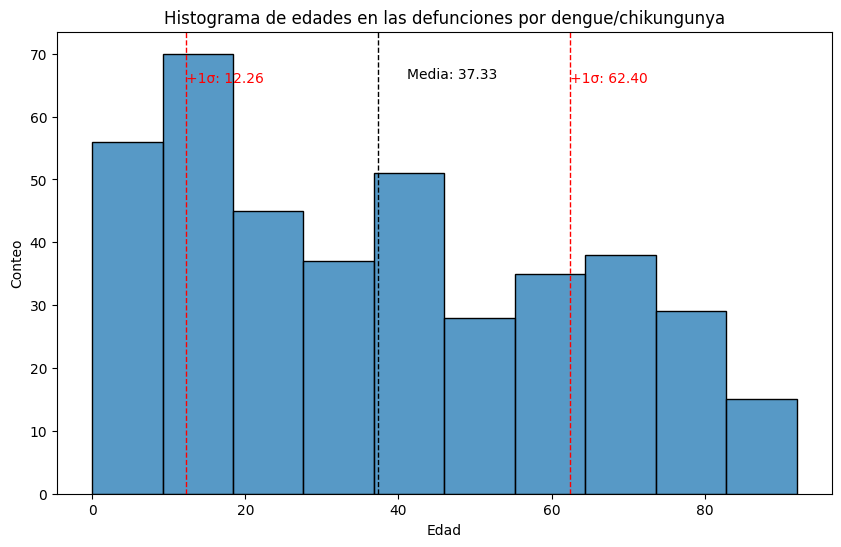

In [27]:
k = int(np.ceil(1+np.log2(len(defun_data)))) #regla de sturges con un numero entero

#Histrograma de edades en las defunciones
media = defun_data['EDAD_ANOS'].mean() #Media de las edades
desv = defun_data['EDAD_ANOS'].std()

plt.figure(figsize=(10, 6))
sns.histplot(data=defun_data, x='EDAD_ANOS', bins = k)
plt.xlabel('Edad')
plt.ylabel('Conteo')
plt.title('Histograma de edades en las defunciones por dengue/chikungunya')

#Limites del histograma en y
min_ylim, max_ylim = plt.ylim()

#Añadir la media al histograma
plt.axvline(media, color='k', linestyle='dashed', linewidth=1)
plt.text(media * 1.1, max_ylim * 0.9, f'Media: {media:.2f}')

#Añadir la desviación estándar al histograma
plt.text(media + desv, max_ylim * 0.9, f'+1σ: {media + desv:.2f}', rotation=0, verticalalignment='center', color='r')
plt.text(media - desv, max_ylim * 0.9, f'+1σ: {media - desv:.2f}', rotation=0, verticalalignment='center', color='r')
plt.axvline(media+desv, color='r', linestyle='dashed', linewidth=1)
plt.axvline(media-desv, color='r', linestyle='dashed', linewidth=1)
plt.savefig("Hist_edad_def", format="png")
plt.show()

<div class="alert alert-block alert-info">
<b>

La media de edades en las defunciones es de 37.33 años y la desviación estándar es de 25.07. Esta desviación tan grande se debe a que la distribución está más cargada a la izquierda y los difuntos con mayor edad son escasos. Probablemente este desbalance sea más debido a los "pocos" datos o a que simplemente en México hay otras causas de muerte más comunes en edades avanzadas que el dengue/chikunguya.

**Ajuste de defunciones**

In [28]:
#distribuciones
distribuciones = ['cauchy', 'chi2', 'expon',  'exponpow', 'gamma',
                  'norm', 'powerlaw', 'beta', 'logistic']

Ajuste1 = defun_data['EDAD_ANOS'] 

# Atributo

fitter = Fitter(Ajuste1, distributions=distribuciones) #Ajuste a las defunciones
fitter.fit()
fitter.summary(Nbest=10, plot=False)



2025-01-15 10:54:52.328 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted expon distribution with error=0.007481)
2025-01-15 10:54:52.331 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted cauchy distribution with error=0.009217)
2025-01-15 10:54:52.341 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted powerlaw distribution with error=0.019812)
2025-01-15 10:54:52.342 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted norm distribution with error=0.00819)
2025-01-15 10:54:52.362 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted logistic distribution with error=0.008405)
2025-01-15 10:54:52.366 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted gamma distribution with error=0.006834)
2025-01-15 10:54:52.414 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted exponpow distribution with error=0.035745)
2025-01-15 10:54:52.417 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted 

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.006275,937.316183,953.321842,inf,0.073463,2.424957e-02
gamma,0.006834,960.328015,972.332259,inf,0.082995,7.201990e-03
expon,0.007481,974.411020,982.413850,inf,0.114010,4.964758e-05
norm,0.008190,956.364872,964.367702,inf,0.091849,2.042065e-03
logistic,0.008405,966.290325,974.293155,inf,0.084666,5.733476e-03
cauchy,0.009217,1019.592476,1027.595305,inf,0.163809,6.100457e-10
powerlaw,0.019812,1289.756978,1301.761223,inf,0.794958,4.196438e-274
exponpow,0.035745,1370.454654,1382.458898,inf,0.796661,1.077856e-275
chi2,0.082755,1662.728277,1674.732521,inf,0.793036,2.535946e-272


Tenemos que la distribucion que mejor se ajusta a los datos de las defunciones es la distribución beta, que se ve de la siguiente forma

<div> <img src="Beta_distribution_pdf.png" alt="Drawing" style="width: 600px;"/></div>

y se escribe como

$$f(x,\alpha,\beta)=\dfrac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)},$$
donde $B(\alpha,\beta)$ es la función Beta dada por

$$B(\alpha,\beta)=\dfrac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)},$$
y donde $\Gamma(\alpha)$ es la función Gamma.

Así, el ajuste se ve de la siguiente forma

2025-01-15 10:54:52.922 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted beta distribution with error=0.006275)


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.006275,937.316183,953.321842,inf,0.073463,0.02425


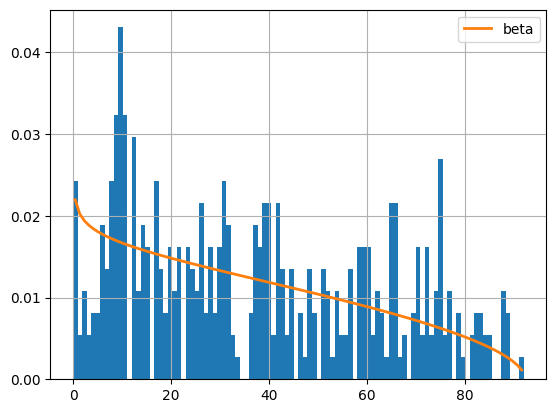

In [29]:
f = Fitter(Ajuste1, distributions=['beta'])
f.fit()
f.summary()

In [30]:
parametro = f.fitted_param['beta']
print("Los valores de los parámetros son", parametro)

Los valores de los parámetros son (0.9300358059751028, 1.5400073632295683, -3.218778676393623e-22, 92.30169864276118)


<div class="alert alert-block alert-info">
<b>

El mejor ajuste para la edad de las defunciones es la distribución beta con parámetros $\alpha=0.93$  y  $\beta=1.54$.

**Ajuste de recuperaciones**

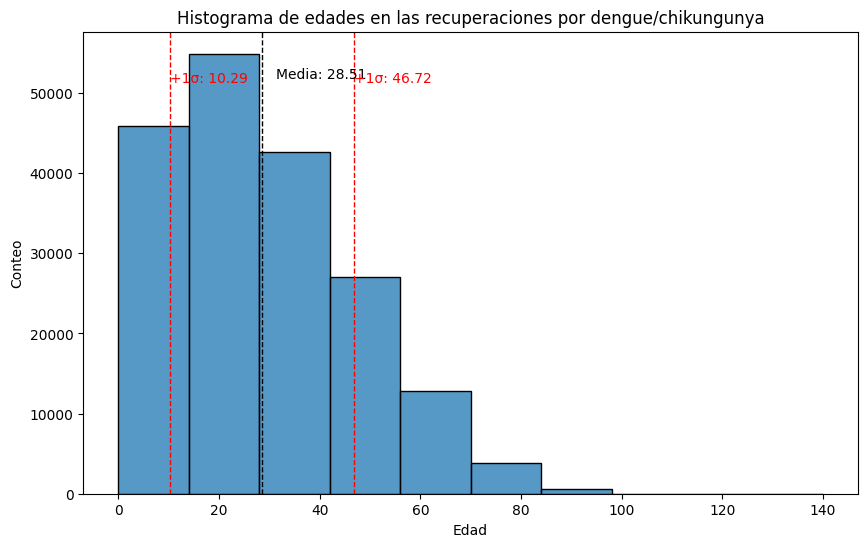

In [31]:
#Histrograma de edades en las defunciones
media = recup_data['EDAD_ANOS'].mean() #Media de las edades
desv = recup_data['EDAD_ANOS'].std()   #Desviación estándar de las edades

plt.figure(figsize=(10, 6))
sns.histplot(data=recup_data, x='EDAD_ANOS', bins = k)
plt.xlabel('Edad')
plt.ylabel('Conteo')
plt.title('Histograma de edades en las recuperaciones por dengue/chikungunya')

#Limites del histograma en y
min_ylim, max_ylim = plt.ylim()

#Añadir la media al histograma
plt.axvline(media, color='k', linestyle='dashed', linewidth=1)
plt.text(media * 1.1, max_ylim * 0.9, f'Media: {media:.2f}')

#Añadir la desviación estándar al histograma
plt.text(media + desv, max_ylim * 0.9, f'+1σ: {media + desv:.2f}', rotation=0, verticalalignment='center', color='r')
plt.text(media - desv, max_ylim * 0.9, f'+1σ: {media - desv:.2f}', rotation=0, verticalalignment='center', color='r')
plt.axvline(media+desv, color='r', linestyle='dashed', linewidth=1)
plt.axvline(media-desv, color='r', linestyle='dashed', linewidth=1)
plt.savefig("Hist_edad_rec", format="png")
plt.show()

<div class="alert alert-block alert-info">
<b>

La media de edades en las recuperaciones es de 28.51 años y la desviación estándar es de 18.21. Esta distribución se encuentra todavía más fuertemente cargada a la izquierda, por lo que la desviación estándar es menor.

In [32]:
#distribuciones
distribuciones = ['cauchy', 'chi2', 'expon',  'exponpow', 'gamma',
                  'norm', 'powerlaw', 'beta', 'logistic']


Ajuste2 = recup_data['EDAD_ANOS']


# Atributo

fitter = Fitter(Ajuste2, distributions=distribuciones)
fitter.fit()
fitter.summary(Nbest=10, plot=False)



2025-01-15 10:54:53.792 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted expon distribution with error=0.003901)
2025-01-15 10:54:53.814 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted norm distribution with error=0.002363)
2025-01-15 10:54:53.861 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted logistic distribution with error=0.002392)
2025-01-15 10:54:53.947 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted cauchy distribution with error=0.003095)
2025-01-15 10:54:54.362 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted gamma distribution with error=0.001651)
2025-01-15 10:54:54.664 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted chi2 distribution with error=0.001651)
2025-01-15 10:54:54.920 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted powerlaw distribution with error=0.013899)
2025-01-15 10:54:55.244 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted bet

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.001561,1586.206332,1626.777926,inf,0.022282,2.066812e-81
chi2,0.001651,1293.692151,1324.120846,inf,0.034401,1.758930e-193
gamma,0.001651,1293.692123,1324.120819,inf,0.034401,1.736124e-193
norm,0.002363,1779.048928,1799.334725,inf,0.074946,0.000000e+00
logistic,0.002392,1437.973348,1458.259145,inf,0.070331,0.000000e+00
cauchy,0.003095,1232.074628,1252.360425,inf,0.139560,0.000000e+00
expon,0.003901,1165.150560,1185.436357,inf,0.151972,0.000000e+00
powerlaw,0.013899,1261.202235,1291.630931,inf,0.644086,0.000000e+00
exponpow,0.017657,1496.487358,1526.916054,inf,0.790770,0.000000e+00


El mejor ajuste también es la distribución beta, y se ve de la forma

2025-01-15 10:54:58.283 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted beta distribution with error=0.001561)


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,0.001561,1586.206332,1626.777926,inf,0.022282,2.066812e-81


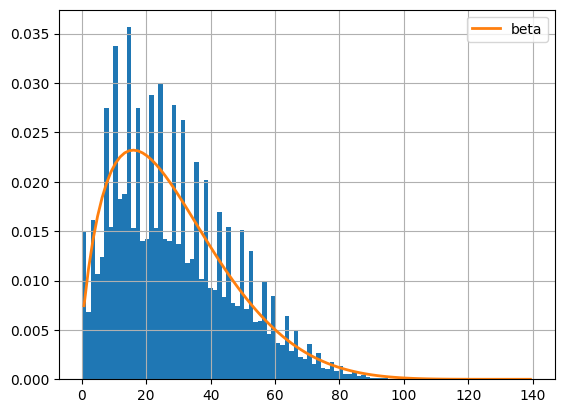

In [33]:
f = Fitter(Ajuste2, distributions=['beta'])
f.fit()
f.summary()

In [34]:
parametro = f.fitted_param['beta']
print("Los valores de los parámetros son", parametro)

Los valores de los parámetros son (1.7989341015492648, 6.8307185307890546, -1.063280140706384, 141.33274992958513)


<div class="alert alert-block alert-info">
<b>

El mejor ajuste para la edad de las defunciones es la distribución beta con parámetros $\alpha=1.80$  y  $\beta=6.83$.

## Regresión lineal ##

En este apartado se estudian los datos utilizando la regresión lineal como modelo supervisado de aprendizaje automatizado (Machine Learning o ML), de tal suerte que se pueda obtener la variable objetivo: la defunción del paciente.

In [35]:
#Modelo de regresión lineal con ML supervisado
def linear_regression_model(data,target_column):
   
    features = data.drop(columns=[target_column])
    target = data[target_column]

    x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42)
    model = LinearRegression()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)**0.5

    print(f'Model Coefficients: {model.coef_}')
    print(f'Model Intercept: {model.intercept_}')
    print('Mean Squared Error: ', mse)
    print('Root Mean Squared Error: ', rmse)
    print('Mean Absolute Error: ', mae)
    print('R2 Score: ', r2)


    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actuales')
    plt.ylabel('Predicho')
    plt.title('Valores Actuales vs Predichos')
    plt.text(0.1, 0.95, f'RMSE: {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.1, 0.85, f'R2 Score: {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    #plt.text(0.05, 0.90, f'Coefficients: {model.coef_}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.show()


Model Coefficients: [-6.59231152e-06 -3.07787046e-05  1.62402352e-05  1.26220894e-04
 -1.65701206e-07 -4.72583876e-03  1.04280375e-02  1.13210137e-03
 -7.62242369e-04  1.41585914e-02  5.96216144e-03  9.68377445e-03
 -1.53438820e-04  2.10391563e-03  3.23843866e-01  2.04462955e-04
  1.53214756e-04  9.78285776e-04]
Model Intercept: 0.29857741990913467
Mean Squared Error:  0.0007661563506885903
Root Mean Squared Error:  0.02767952945208047
Mean Absolute Error:  0.04887417868953579
R2 Score:  0.6074932690562715


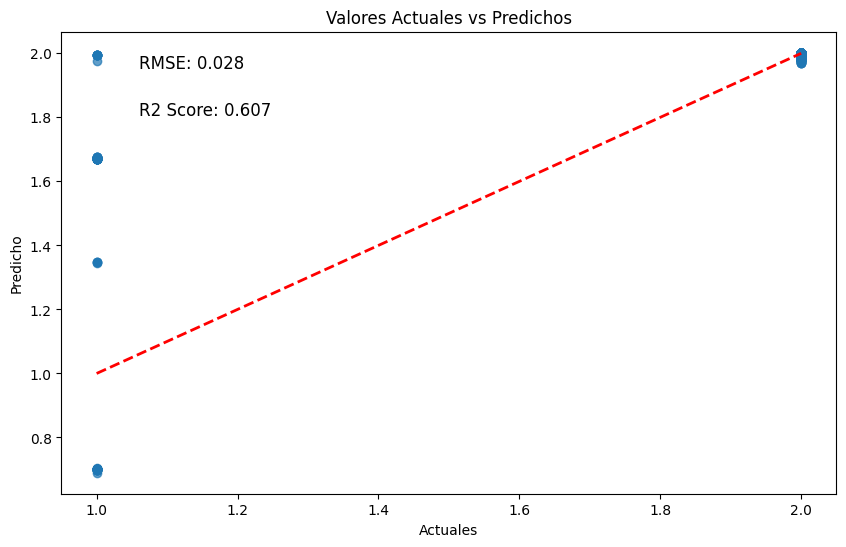

In [36]:
linear_regression_model(dengue_data,'DEFUNCION')

<div class="alert alert-block alert-info">
<b>

Como la defunción del paciente es una variable categórica (1 si falleció y 2 si no falleció), tenemos que la gráfica de la regresión linea parece no decirnos mucho. De hecho nos podría hacer pensar que no se sigue correctamente la linealidad. A pesar de esto, contamos con un RMSE bajo (RMSE $=0.028$) y con un $R^{2}$ Score, si bien mejorable ($R^{2}=0.607$), bastante decente para tratarse justamente de varibles categóricas.

## Regresión logística ##

Como la variable objetivo es categórica, tenemos que la regresión logístiva puede ser un mejor modelo para predecir la posibilidad de que una persona infectada de dengue/chikungunya fallezca; con los valores asignados a 1 para personas fallecidas y 2 para personas recuperadas.

Error Cuadrático Medio (MSE) = 0.00031887755102040814
Raíz del Error Cuadrático Medio (RMSE) = 0.017857142857142856
Coeficiente de Determinación R2 = 0.836637019310912
Error Absoluto Medio (MAE) = 0.017857142857142856


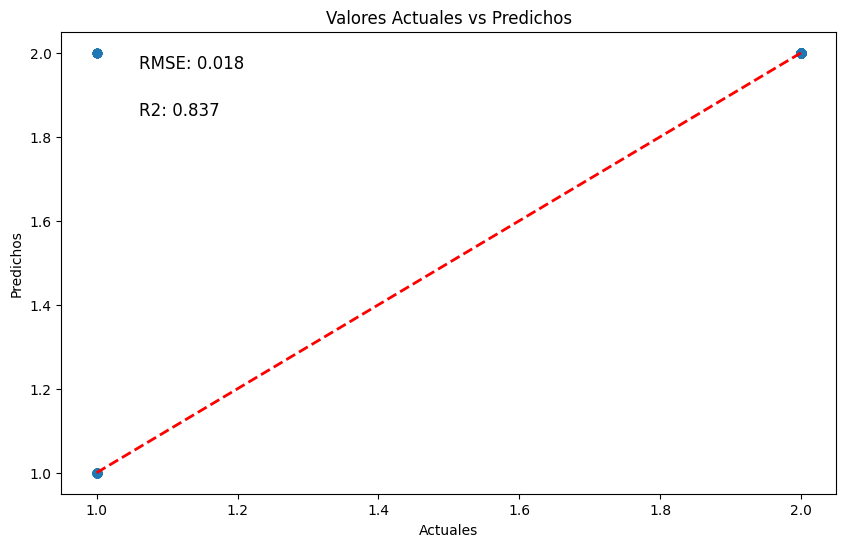

In [37]:
#Separación de nuestra variable objetivo
features = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target = dengue_data['DEFUNCION']                   #Variable objetivo

#------------------------------------------------------------------------------
#Separación en conjunto de entrenamiento y conjunto de prueba (75% y 25 %, respectivamente)

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 

#------------------------------------------------------------------------------
#Entrenamiento de modelo de regresión logística

log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)
y_pred = log_reg.predict(x_test)

#------------------------------------------------------------------------------
#Evaluación de modelo de regresión logística

# Error Cuadrado Medio
mse = mean_squared_error(y_test, y_pred)
# La raíz cuadrada del MSE es el RMSE 
rmse = np.sqrt(mse)
# Coeficiente de determinación R2
r2 = r2_score(y_test, y_pred)
# Error absoluto medio
mae = mean_absolute_error(y_test, y_pred)**0.5

print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
print('Coeficiente de Determinación R2 = ' + str(r2))
print('Error Absoluto Medio (MAE) = ' + str(mae))

#------------------------------------------------------------------------------
#Gráfica de la evaluación
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actuales')
plt.ylabel('Predichos')
plt.title('Valores Actuales vs Predichos')
plt.text(0.1, 0.95, f'RMSE: {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.1, 0.85, f'R2: {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig("LogReg1.png", format="png")
plt.show()



<div class="alert alert-block alert-info">
<b>

En esta gráfica ya encontramos una dispersión menor de los datos de nuestro modelo, obteniendo un RMSE $=0.018$ y un $R^{2}$ Score de $R^{2}=0.837$. Ambos resultados son mejores que los obtenidos con el modelo de regresión lineal, lo que era esperado por la naturaleza categórica de nuestra variable objetivo Defunción.

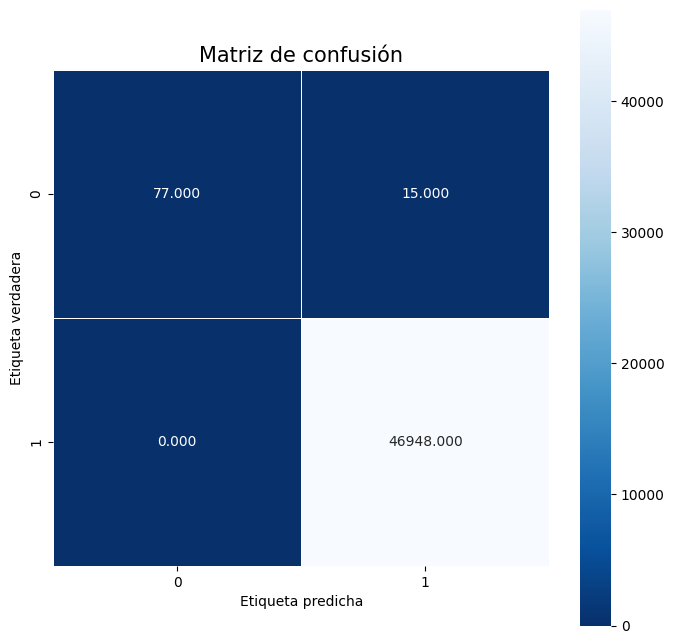

In [38]:
#Matriz de confusión

cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("ConfMatLogRes.png", format="png")

In [39]:
#Matriz de confusión
#y_pred = log_reg.predict(x_train)

#cm = metrics.confusion_matrix(y_train, y_pred)

#plt.figure(figsize=(8,8))
#sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
#plt.ylabel('Etiqueta verdadera')
#plt.xlabel('Etiqueta predicha')
#plt.title('Matriz de confusión', size = 15)

**NOTA:** Es importante mencionar que en este caso tenemos que $1$ representa los positivos y $0$ los negativos, pero la matriz de confusión clasificó el positivo con el "No falleció" y el negativo con el "Sí falleció". Por esto es que de aquí en adelente el modelo calculará predicirá si la persona infectada sobrevive ($1$ positivo) o no sobrevive ($0$ negativo).

Con esto tenemos que el modelo de regresión logística clasificó correctamente 77 defunciones (verdaderos negativos), 46 948 recuperados (verdaderos positivos) y se equivocó clasificando 15 personas fallecidas como recuperadas (falsos positivos).

<div class="alert alert-block alert-info">
<b>

La matriz de confusión muestra valores muy favorables, pues de una muestra 47,040 datos solo hubo 15 datos que clasificó mal. Salta a la vista que existe la posibilidad de que exista un sobre entrenamiento del modelo, pero ya se analizaron algunos cambios en la cantidad de datos de entrenamiento y no se encontró un cambio significativo en la cantidad de falsos negativos y falsos positivos. Por esto es que la regresión logística parece ser un modelo apropiado para este problema en específico.

**Precisión de la regresión logística**

Sensibilidad: 0.8369565217391305
Precisión: 1.0
F1 Score: 0.9112426035502958


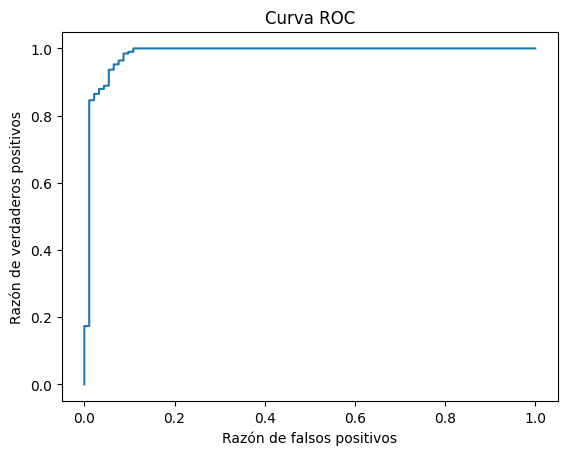

In [40]:
#Precisión de la regresión lineal

print("Sensibilidad:",recall_score(y_test, y_pred))
print("Precisión:",precision_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))

y_pred_proba = log_reg.predict_proba(x_test)[::,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba, pos_label = 2) #Es necesario remarcar que el 2 es el positivo
plt.plot(fpr,tpr)
plt.xlabel('Razón de falsos positivos')
plt.ylabel('Razón de verdaderos positivos')
plt.title('Curva ROC')
plt.show()

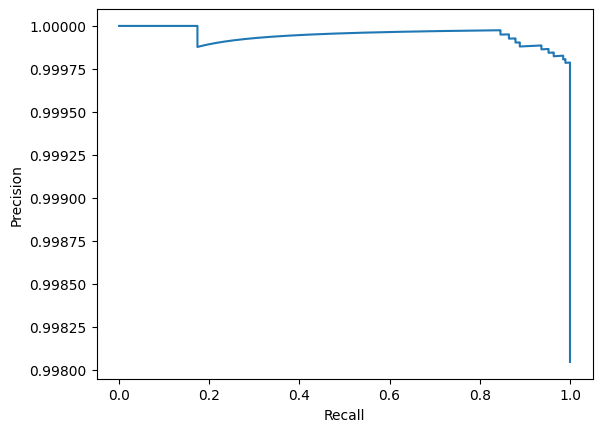

In [41]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba, pos_label = 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

<div class="alert alert-block alert-info">
<b>

Las dos curvas presentan una muy buena aproximación a un modelo ideal, es decir, un modelo sin errores. 

Ahora se va a acomodar los valores de la columna de Defunciones en la base de datos para que los positivos y negativos funcionen acorde las librerías de scikit-learn. 

Así tendrémos dos valores en la columna de Defunción:

-Será $0$ si el paciente no sobrevivió.

-Será $1$ si el paciente sí sobrevivió.

In [42]:
#Cambio de variables para facilidad de manejo

dengue_data['DEFUNCION'] = dengue_data['DEFUNCION'].replace(1, 0)
dengue_data['DEFUNCION'] = dengue_data['DEFUNCION'].replace(2, 1)


Error Cuadrático Medio (MSE) = 0.00031887755102040814
Raíz del Error Cuadrático Medio (RMSE) = 0.017857142857142856
Coeficiente de Determinación R2 = 0.836637019310912
Error Absoluto Medio (MAE) = 0.017857142857142856


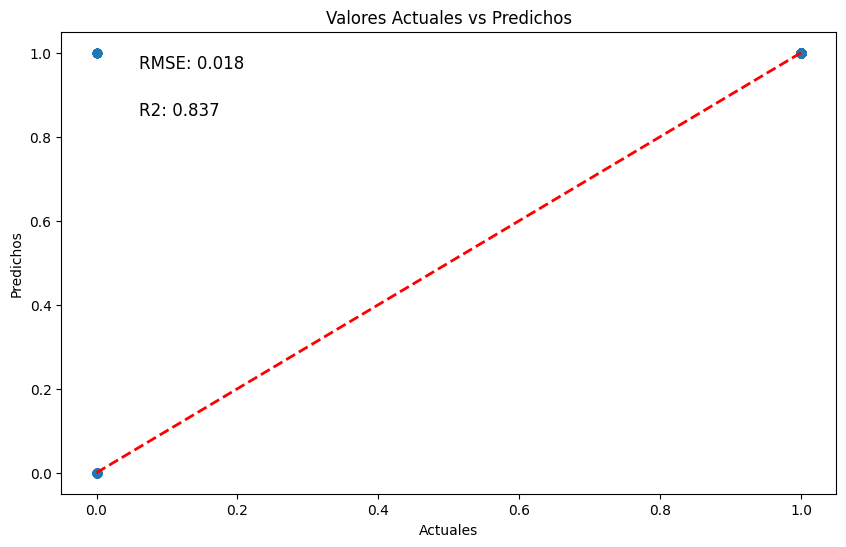

In [43]:
#Separación de nuestra variable objetivo
features = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target = dengue_data['DEFUNCION']                   #Variable objetivo

#------------------------------------------------------------------------------
#Separación en conjunto de entrenamiento y conjunto de prueba (75% y 25 %, respectivamente)

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 

#------------------------------------------------------------------------------
#Entrenamiento de modelo de regresión logística

log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)
y_pred = log_reg.predict(x_test)

#------------------------------------------------------------------------------
#Evaluación de modelo de regresión logística

# Error Cuadrado Medio
mse = mean_squared_error(y_test, y_pred)
# La raíz cuadrada del MSE es el RMSE 
rmse = np.sqrt(mse)
# Coeficiente de determinación R2
r2 = r2_score(y_test, y_pred)
# Error absoluto medio
mae = mean_absolute_error(y_test, y_pred)**0.5

print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
print('Coeficiente de Determinación R2 = ' + str(r2))
print('Error Absoluto Medio (MAE) = ' + str(mae))

#------------------------------------------------------------------------------
#Gráfica de la evaluación
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actuales')
plt.ylabel('Predichos')
plt.title('Valores Actuales vs Predichos')
plt.text(0.1, 0.95, f'RMSE: {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.1, 0.85, f'R2: {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig("LogReg2.png", format="png")
plt.show()



<div class="alert alert-block alert-info">
<b>

Con esto tenemos los mismos valores de RMSE y $R^{2}$ Score, lo que era de esperarse.

In [44]:
#Función para evaluar la precisión del modelo. Calcula Exactitud, F1 Score, APS y ROC AUC.
#Grafica el valor F1, la curva ROC y PCR.

def evaluate_model(model, train_features, train_target, test_features, test_target):
   
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.4f} @ {f1_thresholds[max_f1_score_idx]:.4f}')
        # establecer cruces para algunos umbrales        
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.4f}')
        # establecer cruces para algunos umbrales        
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.4f}')
        # establecer cruces para algunos umbrales        
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')   
        
        eval_stats[type]['Exactitud'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(4)
    df_eval_stats = df_eval_stats.reindex(index=('Exactitud', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return eval_stats['train']['F1'], eval_stats['test']['F1']

            train    test
Exactitud  0.9998  0.9997
F1         0.9999  0.9998
APS        1.0000  0.9999
ROC AUC    0.9955  0.9835


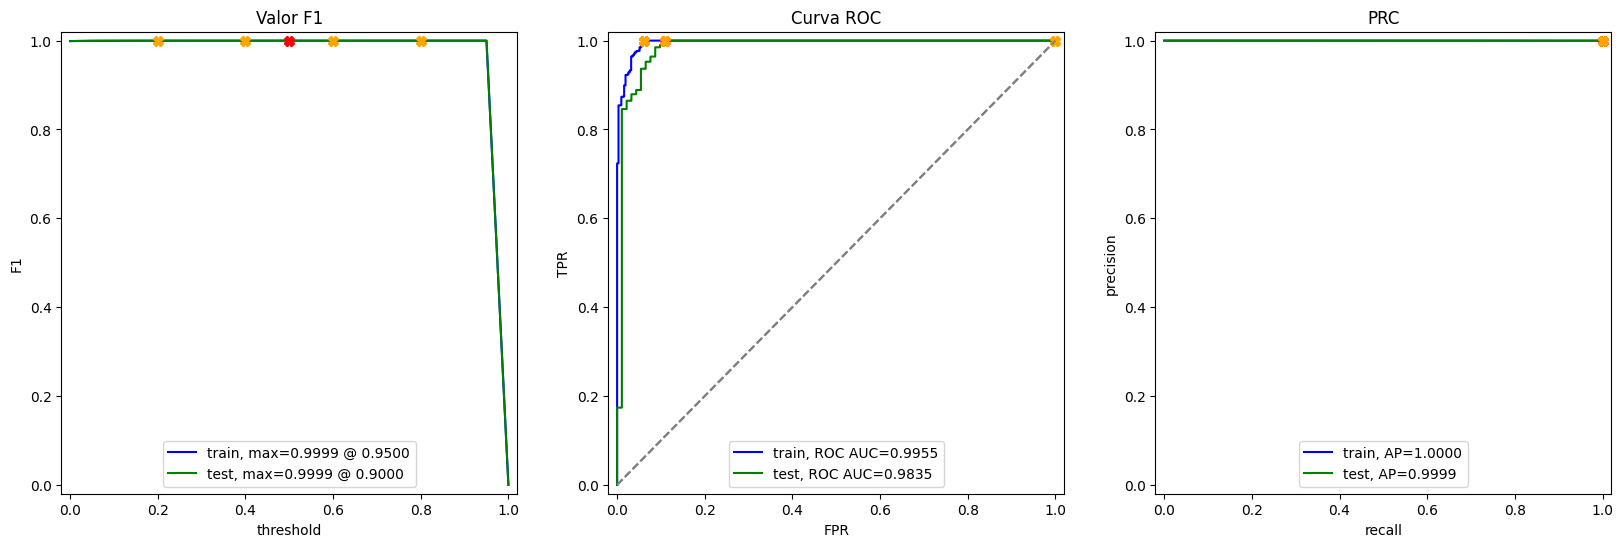

In [45]:
train_f1, test_f1 = evaluate_model(log_reg, x_train, y_train, x_test, y_test)

<div class="alert alert-block alert-info">
<b>

Con esto tenemos que el modelo de regresión logística es ideal para el problema que estamos resolviendo, al tratarse claramente de un problema de clasificación. Solo falta probar modelos más complejos y verificar que la diferencia en el tiempo de cómputo en estos se puede asumir en favor de un mejor modelo, aunque según los valores calculados parece ser poco probable.

## Balanceo de las variables ##

Como se vio en la visualización de los datos, la cantidad de sobrevivientes y no sobrevivientes está desbalanceada, contando con una gran mayoría de personas que sobrevivieron.

In [46]:
def plot_countplots(data, columns, title_prefix="", rotation=45):
    """
    Graficar conteos de valores en columnas categóricas

    data: DataFrame
    columns: Lista de columnas a graficar
    title_prefix: Prefijo para el título de la gráfica
    rotation: Rotación de las etiquetas del eje x
    """
    num_cols = len(columns)
    fig, axes = plt.subplots(num_cols, 1, figsize=(12, 4 * num_cols))
    if num_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, column in enumerate(columns):
        if i < len(axes):
            sns.countplot(ax=axes[i], x=column, data=data)
            axes[i].set_title(f"{title_prefix} - {column}")
            axes[i].tick_params(axis="x", rotation=rotation)
        else:
            print(f"Column '{column}' not found in the DataFrame")
    plt.tight_layout()
    plt.savefig("Count.png", format="png")
    plt.show()


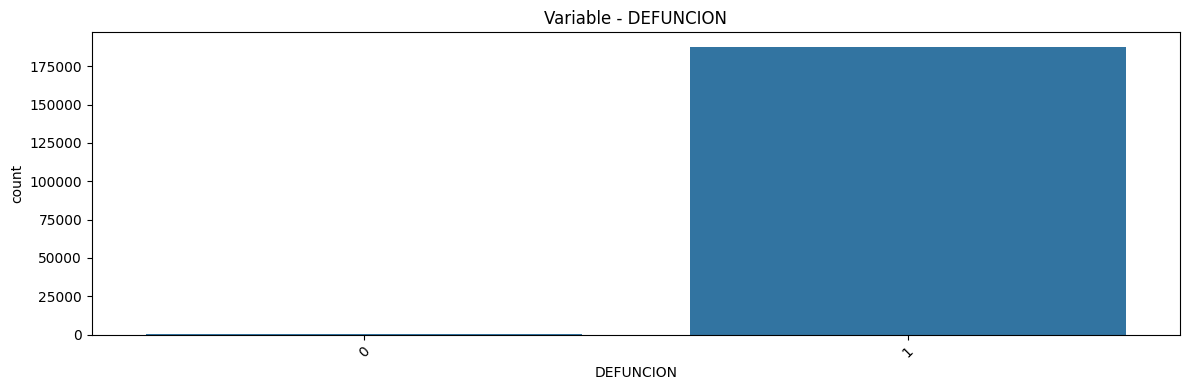

DEFUNCION
1    0.997853
0    0.002147
Name: proportion, dtype: float64


In [47]:
plot_countplots(dengue_data,['DEFUNCION'], "Variable")
class_distribution = dengue_data["DEFUNCION"].value_counts(normalize = True)
print(class_distribution)

Por esto es que se va a estudiar como reacciona el algoritmo de Regresión logística ante un balanceo previo de los datos:

**Balanceo con parámetro class_weight**

/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Error Cuadrático Medio (MSE) = 0.008524659863945579
Raíz del Error Cuadrático Medio (RMSE) = 0.09232908460472018
Coeficiente de Determinación R2 = -3.3672370170882884
Error Absoluto Medio (MAE) = 0.09232908460472018


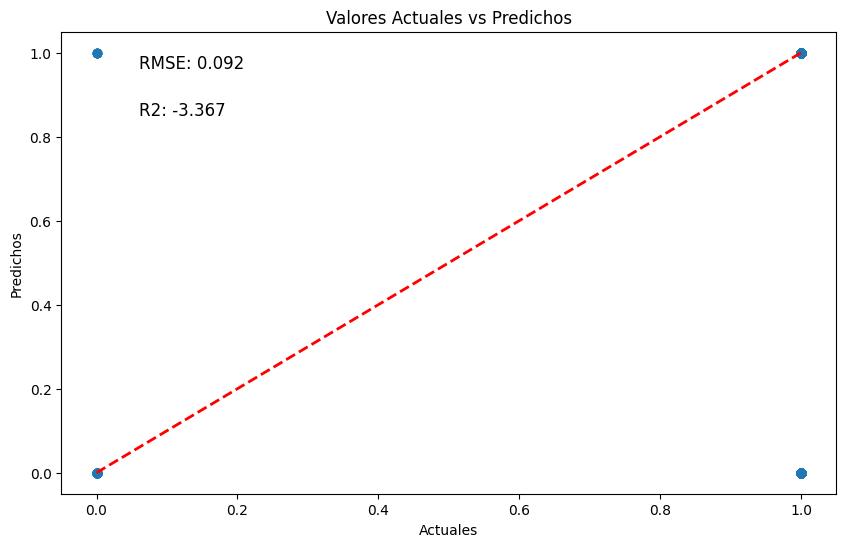

            train    test
Exactitud  0.9924  0.9915
F1         0.9962  0.9957
APS        1.0000  0.9999
ROC AUC    0.9971  0.9839


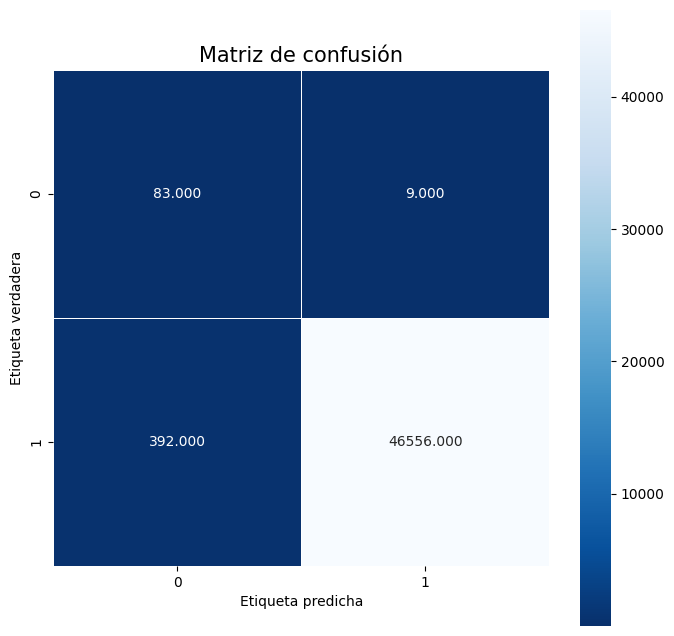

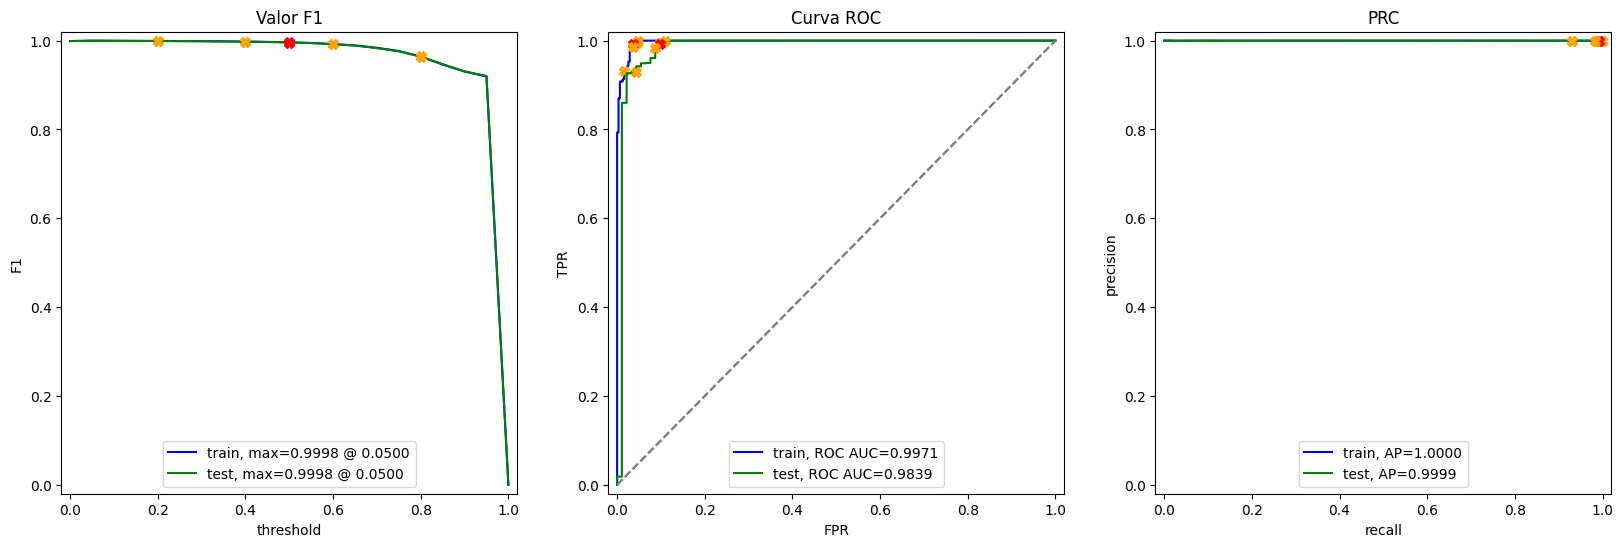

In [48]:
#Separación de nuestra variable objetivo
features = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target = dengue_data['DEFUNCION']                   #Variable objetivo

#------------------------------------------------------------------------------
#Separación en conjunto de entrenamiento y conjunto de prueba (75% y 25 %, respectivamente)

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 

#------------------------------------------------------------------------------
#Entrenamiento de modelo de regresión logística

log_reg = LogisticRegression(class_weight="balanced") #
log_reg.fit(x_train, y_train)
y_pred = log_reg.predict(x_test)

#------------------------------------------------------------------------------
#Evaluación de modelo de regresión logística

# Error Cuadrado Medio
mse = mean_squared_error(y_test, y_pred)
# La raíz cuadrada del MSE es el RMSE 
rmse = np.sqrt(mse)
# Coeficiente de determinación R2
r2 = r2_score(y_test, y_pred)
# Error absoluto medio
mae = mean_absolute_error(y_test, y_pred)**0.5

print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
print('Coeficiente de Determinación R2 = ' + str(r2))
print('Error Absoluto Medio (MAE) = ' + str(mae))

#------------------------------------------------------------------------------
#Gráfica de la evaluación
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actuales')
plt.ylabel('Predichos')
plt.title('Valores Actuales vs Predichos')
plt.text(0.1, 0.95, f'RMSE: {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.1, 0.85, f'R2: {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig("class_weight.png", format="png")
plt.show()

#Matriz de confusión

cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("ConfMat_class_weight.png", format="png")

train_f1, test_f1 = evaluate_model(log_reg, x_train, y_train, x_test, y_test)


**Balanceo con SMOTE**

/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and w

before resampling Counter({1: 140808, 0: 312})
after resampling Counter({1: 140808, 0: 140808})


/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Error Cuadrático Medio (MSE) = 0.019244696259691572
Raíz del Error Cuadrático Medio (RMSE) = 0.1387252545850667
Coeficiente de Determinación R2 = 0.9230212149612337
Error Absoluto Medio (MAE) = 0.1387252545850667


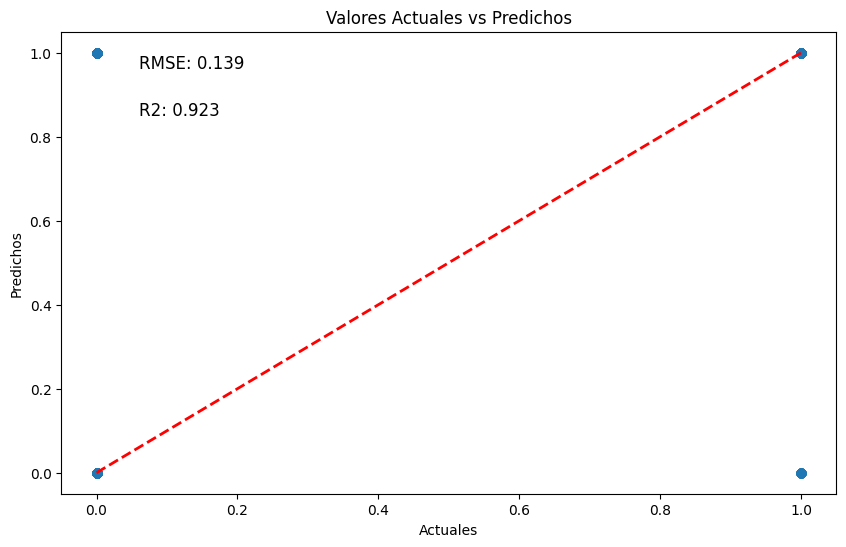

            train    test
Exactitud  0.9931  0.9973
F1         0.9931  0.9986
APS        0.9993  0.9998
ROC AUC    0.9995  0.9828


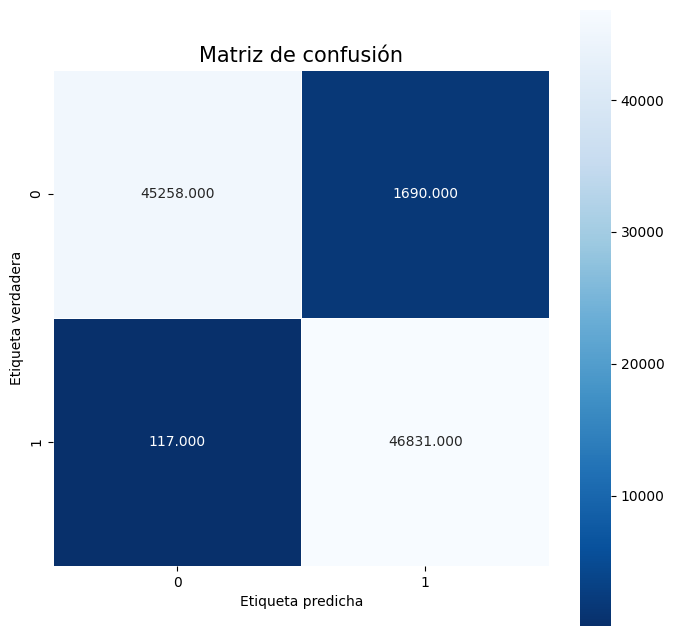

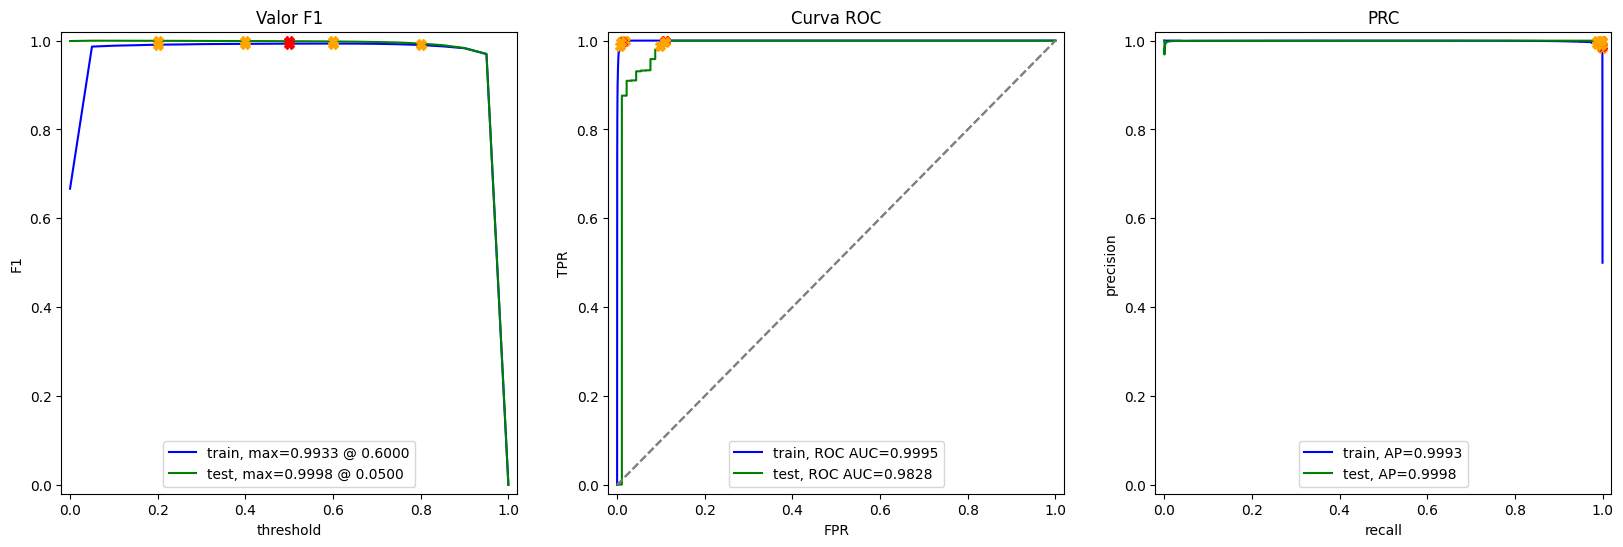

In [49]:
#Separación de nuestra variable objetivo
features = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target = dengue_data['DEFUNCION']                   #Variable objetivo

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 

os_us = SMOTE()
x_train_res, y_train_res = os_us.fit_resample(x_train, y_train)
x_test_res, y_test_res = os_us.fit_resample(x_test, y_test)
 
print ("before resampling {}".format(Counter(y_train)))
print ("after resampling {}".format(Counter(y_train_res)))

#Entrenamiento de modelo de regresión logística

log_reg = LogisticRegression()
log_reg.fit(x_train_res, y_train_res)
y_pred = log_reg.predict(x_test_res)

#------------------------------------------------------------------------------
#Evaluación de modelo de regresión logística

# Error Cuadrado Medio
mse = mean_squared_error(y_test_res, y_pred)
# La raíz cuadrada del MSE es el RMSE 
rmse = np.sqrt(mse)
# Coeficiente de determinación R2
r2 = r2_score(y_test_res, y_pred)
# Error absoluto medio
mae = mean_absolute_error(y_test_res, y_pred)**0.5

print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
print('Coeficiente de Determinación R2 = ' + str(r2))
print('Error Absoluto Medio (MAE) = ' + str(mae))

#------------------------------------------------------------------------------
#Gráfica de la evaluación
plt.figure(figsize=(10, 6))
plt.scatter(y_test_res, y_pred, alpha=0.7)
plt.plot([y_test_res.min(), y_test_res.max()], [y_test_res.min(), y_test_res.max()], 'r--', lw=2)
plt.xlabel('Actuales')
plt.ylabel('Predichos')
plt.title('Valores Actuales vs Predichos')
plt.text(0.1, 0.95, f'RMSE: {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.1, 0.85, f'R2: {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig("SMOTE.png", format="png")
plt.show()

#Matriz de confusión

cm = metrics.confusion_matrix(y_test_res, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("ConfMat_SMOTE.png", format="png")

train_f1, test_f1 = evaluate_model(log_reg, x_train_res, y_train_res, x_test, y_test)


**Balanceo con SMOTETomek**

/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTETomek or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 

before resampling Counter({1: 140808, 0: 312})
after resampling Counter({1: 140808, 0: 140808})


/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Error Cuadrático Medio (MSE) = 0.018211638408451903
Raíz del Error Cuadrático Medio (RMSE) = 0.13495050355019764
Coeficiente de Determinación R2 = 0.9271534463661923
Error Absoluto Medio (MAE) = 0.13495050355019764


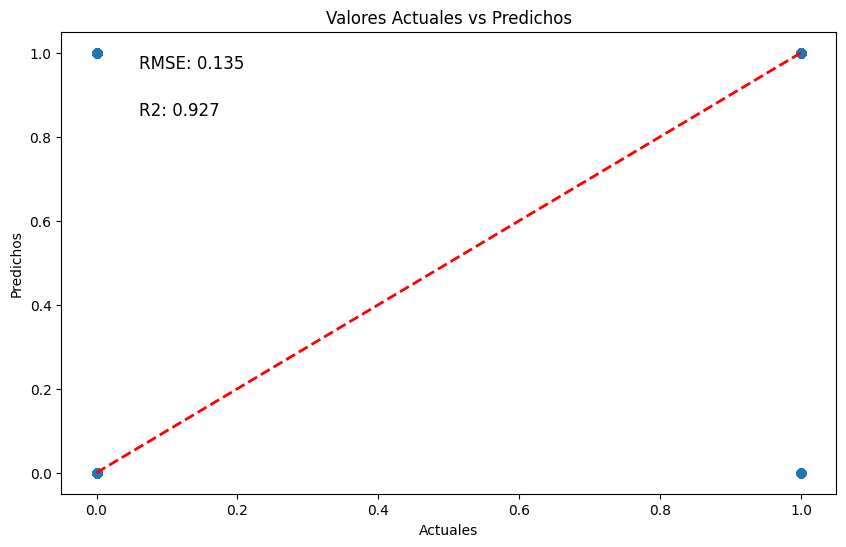

            train    test
Exactitud  0.9937  0.9975
F1         0.9937  0.9988
APS        0.9994  0.9998
ROC AUC    0.9995  0.9833


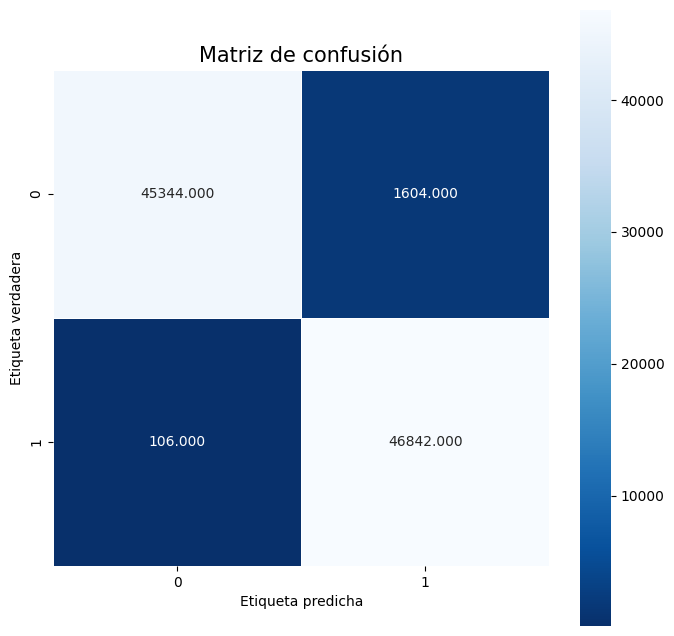

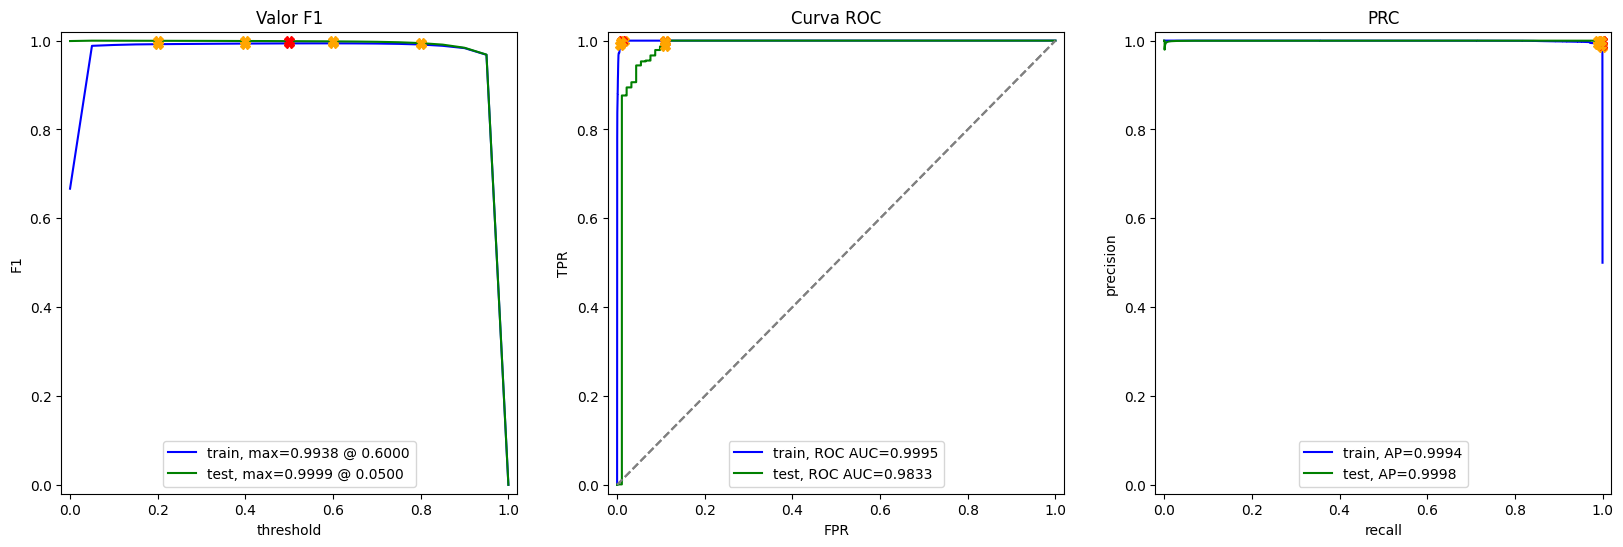

In [50]:
#Separación de nuestra variable objetivo
features = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target = dengue_data['DEFUNCION']                   #Variable objetivo

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 

os_us = SMOTETomek()
x_train_res, y_train_res = os_us.fit_resample(x_train, y_train)
x_test_res, y_test_res = os_us.fit_resample(x_test, y_test)
 
print ("before resampling {}".format(Counter(y_train)))
print ("after resampling {}".format(Counter(y_train_res)))

#Entrenamiento de modelo de regresión logística

log_reg = LogisticRegression()
log_reg.fit(x_train_res, y_train_res)
y_pred = log_reg.predict(x_test_res)

#------------------------------------------------------------------------------
#Evaluación de modelo de regresión logística

# Error Cuadrado Medio
mse = mean_squared_error(y_test_res, y_pred)
# La raíz cuadrada del MSE es el RMSE 
rmse = np.sqrt(mse)
# Coeficiente de determinación R2
r2 = r2_score(y_test_res, y_pred)
# Error absoluto medio
mae = mean_absolute_error(y_test_res, y_pred)**0.5

print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
print('Coeficiente de Determinación R2 = ' + str(r2))
print('Error Absoluto Medio (MAE) = ' + str(mae))

#------------------------------------------------------------------------------
#Gráfica de la evaluación
plt.figure(figsize=(10, 6))
plt.scatter(y_test_res, y_pred, alpha=0.7)
plt.plot([y_test_res.min(), y_test_res.max()], [y_test_res.min(), y_test_res.max()], 'r--', lw=2)
plt.xlabel('Actuales')
plt.ylabel('Predichos')
plt.title('Valores Actuales vs Predichos')
plt.text(0.1, 0.95, f'RMSE: {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.1, 0.85, f'R2: {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig("SMOTETomek", format="png")
plt.show()

#Matriz de confusión

cm = metrics.confusion_matrix(y_test_res, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("ConfMat_SMOTETomek.png", format="png")

train_f1, test_f1 = evaluate_model(log_reg, x_train_res, y_train_res, x_test, y_test)


**Balanceo con NearMiss**

/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The NearMiss or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 an

before resampling Counter({1: 140808, 0: 312})
after resampling Counter({0: 312, 1: 312})
Error Cuadrático Medio (MSE) = 0.1358695652173913
Raíz del Error Cuadrático Medio (RMSE) = 0.3686048903872428
Coeficiente de Determinación R2 = 0.4565217391304348
Error Absoluto Medio (MAE) = 0.3686048903872428


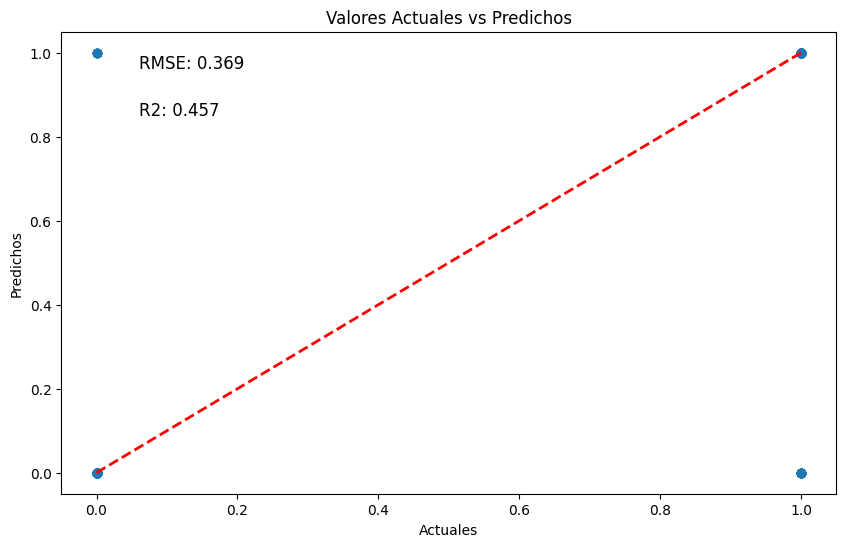

            train    test
Exactitud  0.9888  0.7479
F1         0.9889  0.8554
APS        0.9798  0.9998
ROC AUC    0.9919  0.9407


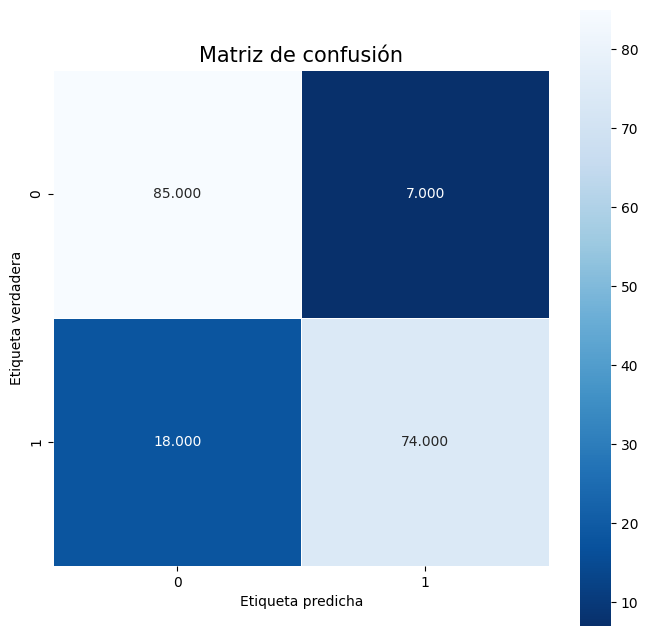

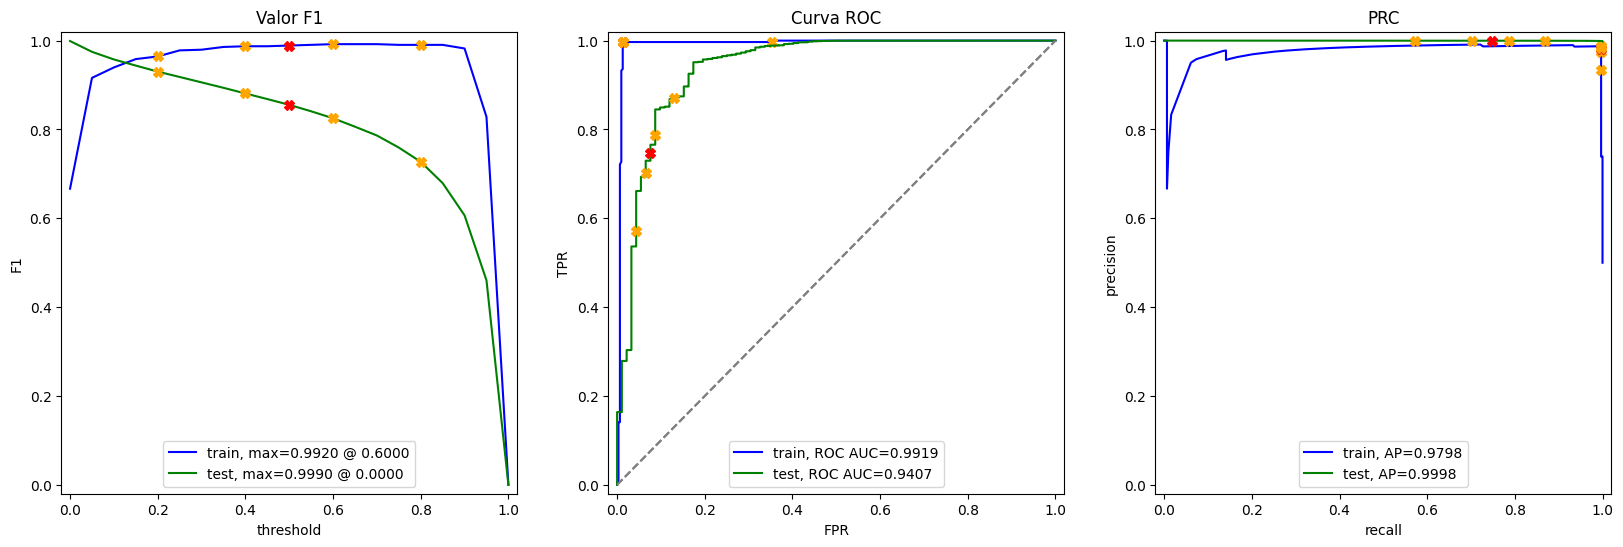

In [51]:
#Separación de nuestra variable objetivo
features = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target = dengue_data['DEFUNCION']                   #Variable objetivo

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 

os_us = NearMiss()
x_train_res, y_train_res = os_us.fit_resample(x_train, y_train)
x_test_res, y_test_res = os_us.fit_resample(x_test, y_test)
 
print ("before resampling {}".format(Counter(y_train)))
print ("after resampling {}".format(Counter(y_train_res)))

#Entrenamiento de modelo de regresión logística

log_reg = LogisticRegression()
log_reg.fit(x_train_res, y_train_res)
y_pred = log_reg.predict(x_test_res)

#------------------------------------------------------------------------------
#Evaluación de modelo de regresión logística

# Error Cuadrado Medio
mse = mean_squared_error(y_test_res, y_pred)
# La raíz cuadrada del MSE es el RMSE 
rmse = np.sqrt(mse)
# Coeficiente de determinación R2
r2 = r2_score(y_test_res, y_pred)
# Error absoluto medio
mae = mean_absolute_error(y_test_res, y_pred)**0.5

print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
print('Coeficiente de Determinación R2 = ' + str(r2))
print('Error Absoluto Medio (MAE) = ' + str(mae))

#------------------------------------------------------------------------------
#Gráfica de la evaluación
plt.figure(figsize=(10, 6))
plt.scatter(y_test_res, y_pred, alpha=0.7)
plt.plot([y_test_res.min(), y_test_res.max()], [y_test_res.min(), y_test_res.max()], 'r--', lw=2)
plt.xlabel('Actuales')
plt.ylabel('Predichos')
plt.title('Valores Actuales vs Predichos')
plt.text(0.1, 0.95, f'RMSE: {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.1, 0.85, f'R2: {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig("NearMiss.png", format="png")
plt.show()

#Matriz de confusión

cm = metrics.confusion_matrix(y_test_res, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("ConfMat_NearMiss.png", format="png")

train_f1, test_f1 = evaluate_model(log_reg, x_train_res, y_train_res, x_test, y_test)

**Balanceo con RandomOverSampler**

/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
 

before resampling Counter({1: 140808, 0: 312})
after resampling Counter({1: 140808, 0: 140808})


/home/eduardo_tirado/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Error Cuadrático Medio (MSE) = 0.054592314901593254
Raíz del Error Cuadrático Medio (RMSE) = 0.23364998373976673
Coeficiente de Determinación R2 = 0.781630740393627
Error Absoluto Medio (MAE) = 0.23364998373976673


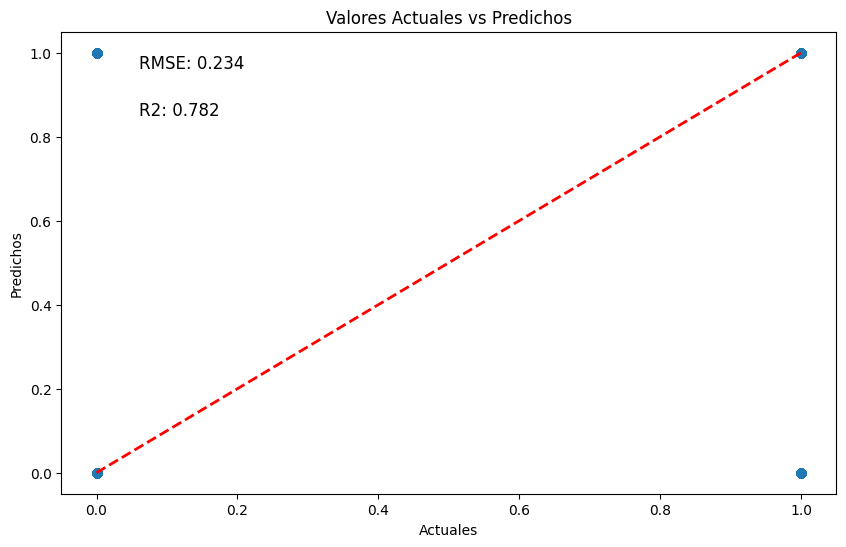

            train    test
Exactitud  0.9784  0.9915
F1         0.9787  0.9957
APS        0.9969  0.9999
ROC AUC    0.9970  0.9840


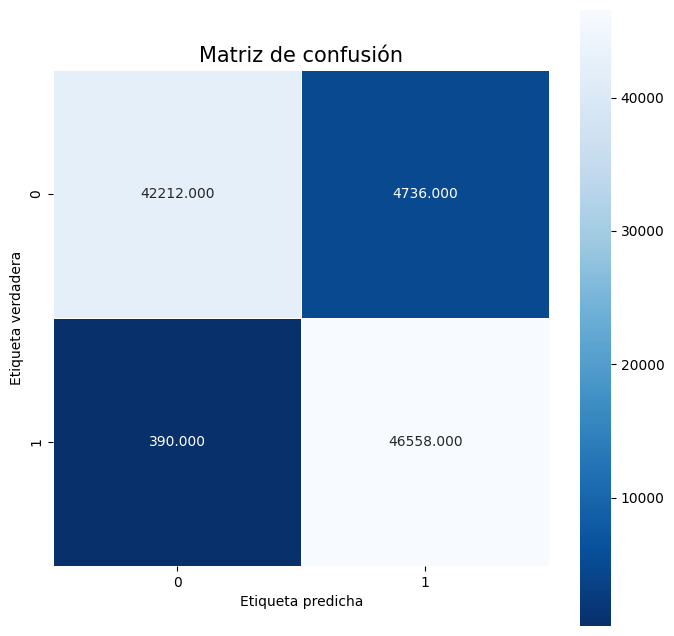

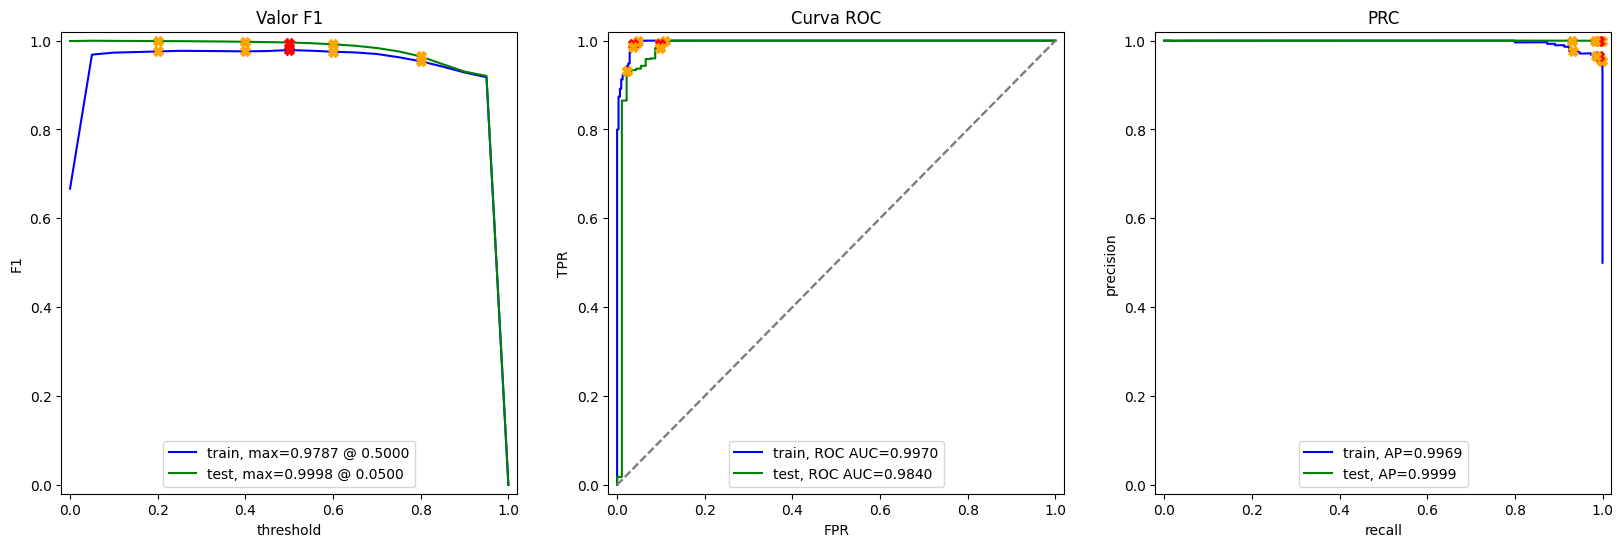

In [52]:
#Separación de nuestra variable objetivo
features = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target = dengue_data['DEFUNCION']                   #Variable objetivo

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 

os_us = RandomOverSampler()
x_train_res, y_train_res = os_us.fit_resample(x_train, y_train)
x_test_res, y_test_res = os_us.fit_resample(x_test, y_test)
 
print ("before resampling {}".format(Counter(y_train)))
print ("after resampling {}".format(Counter(y_train_res)))

#Entrenamiento de modelo de regresión logística

log_reg = LogisticRegression()
log_reg.fit(x_train_res, y_train_res)
y_pred = log_reg.predict(x_test_res)

#------------------------------------------------------------------------------
#Evaluación de modelo de regresión logística

# Error Cuadrado Medio
mse = mean_squared_error(y_test_res, y_pred)
# La raíz cuadrada del MSE es el RMSE 
rmse = np.sqrt(mse)
# Coeficiente de determinación R2
r2 = r2_score(y_test_res, y_pred)
# Error absoluto medio
mae = mean_absolute_error(y_test_res, y_pred)**0.5

print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
print('Coeficiente de Determinación R2 = ' + str(r2))
print('Error Absoluto Medio (MAE) = ' + str(mae))

#------------------------------------------------------------------------------
#Gráfica de la evaluación
plt.figure(figsize=(10, 6))
plt.scatter(y_test_res, y_pred, alpha=0.7)
plt.plot([y_test_res.min(), y_test_res.max()], [y_test_res.min(), y_test_res.max()], 'r--', lw=2)
plt.xlabel('Actuales')
plt.ylabel('Predichos')
plt.title('Valores Actuales vs Predichos')
plt.text(0.1, 0.95, f'RMSE: {rmse:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.1, 0.85, f'R2: {r2:.3f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig("RandomOverSampler.png", format="png")
plt.show()

#Matriz de confusión

cm = metrics.confusion_matrix(y_test_res, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("ConfMat_RandomOverSamplerRegresión logística.png", format="png")

train_f1, test_f1 = evaluate_model(log_reg, x_train_res, y_train_res, x_test, y_test)

<div class="alert alert-block alert-info">
<b>

Debido a que, en general, los errores se ven aumentados con los métodos de balanceo y a que en su mayoría se ve necesario balancear tanto el conjunto de datos de prueba como los de entrenamiento, es que se seguirá trabajando con los valores sin balancear.

Considérese que esto no es un problema a priori siendo que la fiabilidad de estos métodos no se ve comprometida, pues parecen caracterizar de manera correcta los datos utilizados y en gran medida permiten visualizar de manera sencilla los resultados de dicha caracterización, facilitando saber si la persona sobrevivió o no.

## Árboles de decisión ##

Ahora probaremos el modelo de árboles de decisión para nuestro problema de clasificación. Es importante utilizar el árbol de decisión para clasificar, pues también existe uno para valores continuos (árbol de decisión de regresión).

In [53]:
#Separación de nuestra variable objetivo
features2 = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target2 = dengue_data['DEFUNCION']                   #Variable objetivo

#------------------------------------------------------------------------------------------------------
#Separación en conjunto de entrenamiento y conjunto de prueba (75% y 25 %, respectivamente)

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 
#------------------------------------------------------------------------------------------------------
#Entrenamiento del modelo

model = DecisionTreeClassifier(random_state=12345)

model.fit(x_train, y_train)

train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

print('Exactitud')
print('Training set:', accuracy_score(y_train, train_predictions))
print('Test set:', accuracy_score(y_test, test_predictions))

Exactitud
Training set: 0.9999645691609977
Test set: 0.9996598639455783


<div class="alert alert-block alert-info">
<b>

 De nuevo tenemos que este modelo es muy cercano al valor ideal, pues la exactitud es casi $1$, lo que nos dice que el número de errores es mínimo. A pesar de esto, es interesante corroborar si se puede obtener una mejor precisión aumentando la profundidad del modelo.

Exactitud de max_depth igual a 1
Conjunto de entrenamiento: 0.9998653628117914
Conjunto de prueba: 0.9997874149659864

Exactitud de max_depth igual a 2
Conjunto de entrenamiento: 0.9998653628117914
Conjunto de prueba: 0.9997874149659864

Exactitud de max_depth igual a 3
Conjunto de entrenamiento: 0.9998653628117914
Conjunto de prueba: 0.9997874149659864

Exactitud de max_depth igual a 4
Conjunto de entrenamiento: 0.9998653628117914
Conjunto de prueba: 0.9997874149659864

Exactitud de max_depth igual a 5
Conjunto de entrenamiento: 0.9998653628117914
Conjunto de prueba: 0.999766156462585

Exactitud de max_depth igual a 6
Conjunto de entrenamiento: 0.9998724489795918
Conjunto de prueba: 0.999766156462585

Exactitud de max_depth igual a 7
Conjunto de entrenamiento: 0.9998795351473923
Conjunto de prueba: 0.999766156462585

Exactitud de max_depth igual a 8
Conjunto de entrenamiento: 0.9998795351473923
Conjunto de prueba: 0.999766156462585

Exactitud de max_depth igual a 9
Conjunto de entrena

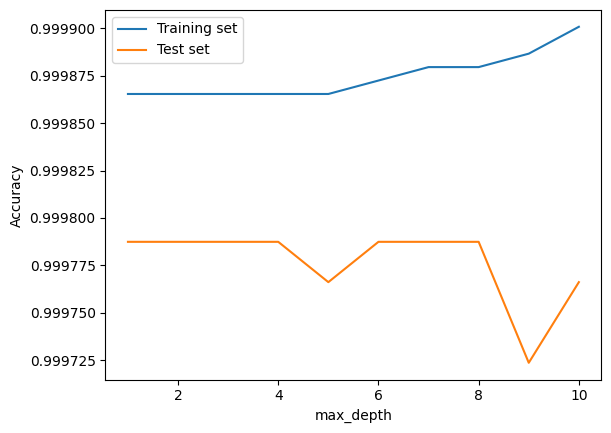

In [54]:
#Busqueda de una profundidad óptima

for depth in range(1, 11):
    model = DecisionTreeClassifier(random_state=54321, max_depth=depth)
    model.fit(x_train, y_train)
    train_predictions = model.predict(x_train)
    test_predictions = model.predict(x_test)
    print("Exactitud de max_depth igual a", depth)
    print("Conjunto de entrenamiento:", accuracy_score(y_train, train_predictions))
    print("Conjunto de prueba:", accuracy_score(y_test, test_predictions))
    print()


train_accuracies = []
test_accuracies = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    model.fit(x_train, y_train)
    train_predictions = model.predict(x_train)
    test_predictions = model.predict(x_test)
    train_accuracies.append(accuracy_score(y_train, train_predictions))
    test_accuracies.append(accuracy_score(y_test, test_predictions))

plt.plot(range(1, 11), train_accuracies, label='Training set')

plt.plot(range(1, 11), test_accuracies, label='Test set')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


<div class="alert alert-block alert-info">
<b>

Se puede apreciar que el cambio en la profundidad es insignificante para la precisión, pues esta tiene cambios hasta los valores $10^{-4}$. Así, verificando numéricamente tenemos que:

In [55]:
best_score = 0
best_est = 0
for depth in range(1, 11):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    model.fit(x_train, y_train)
    score = model.score(x_test, y_test)
    if score > best_score:
        best_score = score
        best_est = depth

print("La exactitud del mejor modelo en el conjunto de validación (n_estimators = {}): {}".format(best_est, best_score))

La exactitud del mejor modelo en el conjunto de validación (n_estimators = 1): 0.9997874149659864


Ahora, se usa Grid Search para corroborar varios hiperparámetros al mismo tiempo: el criterio, la profundidad, la división de la muestra y el número de hojas.

In [56]:
# Definir el modelo
model = DecisionTreeClassifier()

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 1, 10, 20],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Configurar Grid Search con validación cruzada
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

# Entrenar el modelo con Grid Search
grid_search.fit(x_train, y_train)

# Imprimir los mejores hiperparámetros y el mejor puntaje
print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor precisión:", grid_search.best_score_)


Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor precisión: 0.9998653628117914


Para conocer mejor las variables tomadas en cuenta en nuestro modelo, se calcula la importancia de las variables utilizadas en el modelo para predecir la defunción y se grafican estos valores.

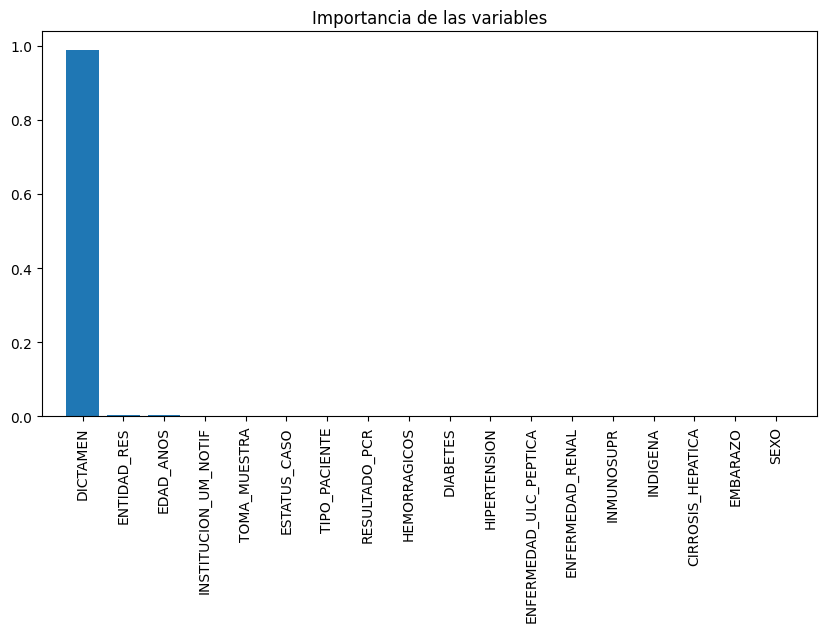

In [57]:
# Mostrar la importancia de las características

# Modelo decision tree con parametros optimizados
best_model = grid_search.best_estimator_
# Predictions
predictions = best_model.predict(x_test)

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Importancia de las variables")
plt.bar(range(x_train.shape[1]), importances[indices], align="center")
plt.xticks(range(x_train.shape[1]), features.columns[indices], rotation=90)
plt.xlim([-1, x_train.shape[1]])
plt.savefig("Importancia.png", format="png")
plt.show()

<div class="alert alert-block alert-info">
<b>

Con esto podemos concluir que efectivamente el sexo del paciente no es una variable representativa en la supervivencia de este, lo que habíamos plantedo en la exploración de los datos.

También tenemos que la variable de Dictamen es la que tiene mayor peso en la predicción, siendo mucho mayor que todas las demás. Esta variable nos dice si se confirmó el dengue/chikungunya, si sigue en estudio o si no aplica, por lo que podemos entender que esto nos ayude a poder dar un mejor diagnóstico de la enfermedad y un mejor tratamiento. Así es que se puede saber si el paciente sobrevive o no.

Por último, se verifica la precisión del modelo utilizando los valores de hiperparámetros obtenidos:

            train    test
Exactitud  0.9999  0.9998
F1         0.9999  0.9999
APS        1.0000  0.9998
ROC AUC    1.0000  0.9456


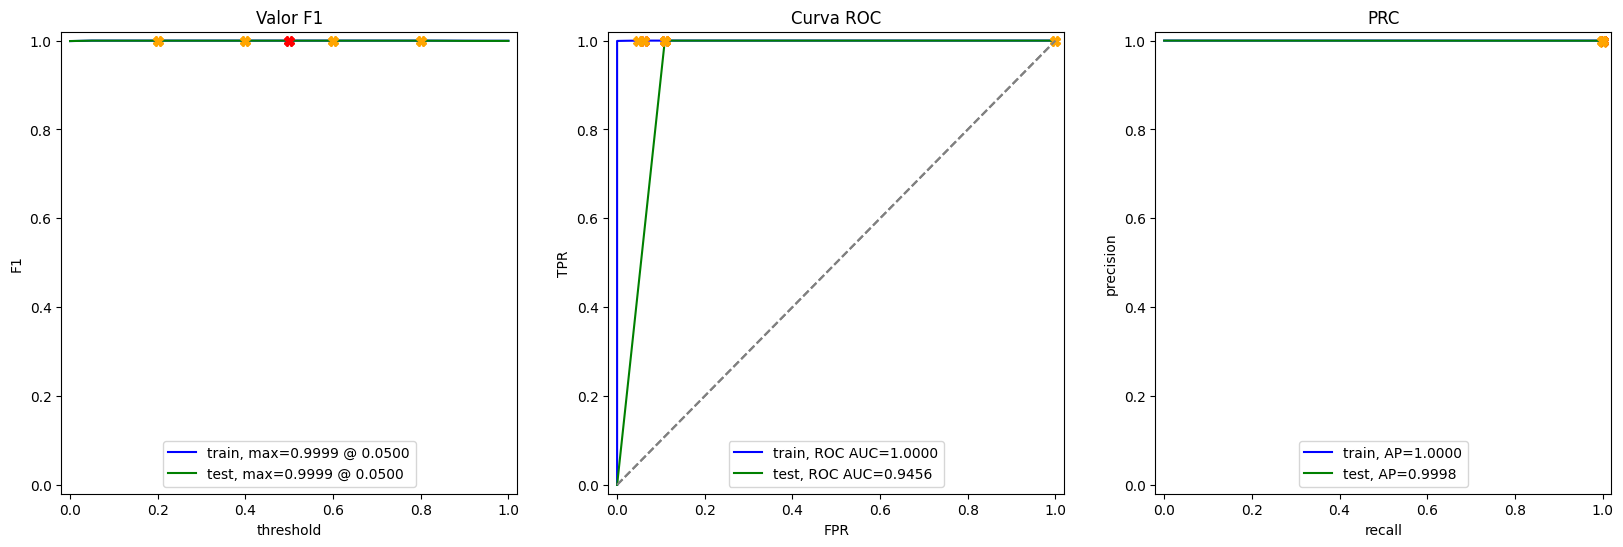

In [58]:
#Árbol de decisión optimizado

Dec_Tree = DecisionTreeClassifier(criterion='gini', min_samples_leaf = 5, min_samples_split = 2)

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42) 

Dec_Tree.fit(x_train, y_train)

train_f1, test_f1 = evaluate_model(Dec_Tree, x_train, y_train, x_test, y_test)

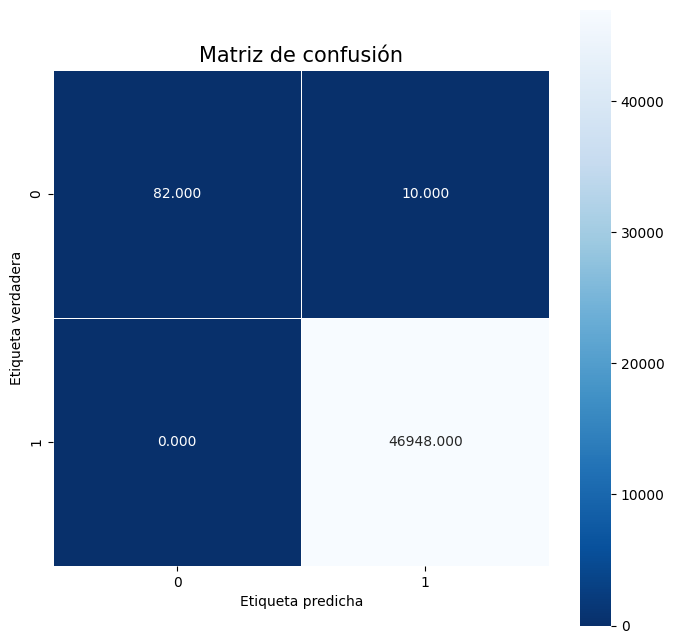

In [59]:
y_pred = Dec_Tree.predict(x_test)

#Matriz de confusión

cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("ConfMatTree.png", format="png")

<div class="alert alert-block alert-info">
<b>

 El modelo de árboles de decisión muestra una ligera mejora en precisión comparado con el modelo de regresión lineal, sobre todo en la curva ROC, y en la matriz de confusión se reduce el número de falsos positivos a 10. 


## Bosque aleatorio ##

Primero se buscará cuál es la cantidad de núcleos óptimos que se pueden utilizar para el modelo de bosque aleatorio. El equipo utilizado tiene 28 núcleos, por lo que se probará el tiempo de cómputo de 1 a 20 núcleos, pero es importante que se verifique la cantidad de núcleos con el que cuenta cada equipo de cómputo que se vaya a utilizar.

>Núcleos = 1: 5.298 segundos
>Núcleos = 2: 3.758 segundos
>Núcleos = 3: 2.456 segundos
>Núcleos = 4: 2.082 segundos
>Núcleos = 5: 1.873 segundos
>Núcleos = 6: 1.834 segundos
>Núcleos = 7: 1.183 segundos
>Núcleos = 8: 1.774 segundos
>Núcleos = 9: 0.979 segundos
>Núcleos = 10: 1.744 segundos
>Núcleos = 11: 0.896 segundos
>Núcleos = 12: 0.842 segundos
>Núcleos = 13: 0.889 segundos
>Núcleos = 14: 0.864 segundos
>Núcleos = 15: 1.797 segundos
>Núcleos = 16: 0.743 segundos
>Núcleos = 17: 0.878 segundos
>Núcleos = 18: 0.852 segundos
>Núcleos = 19: 0.721 segundos
>Núcleos = 20: 0.732 segundos
Mejor número de núcleos: 19
Mejor tiempo: 0.721


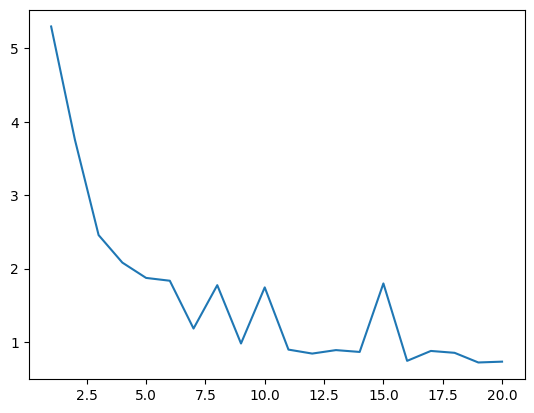

In [60]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=3)
results = list()
# Comparar el tiempo de cómputo para n cantidad de núcleos
n_cores = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] #Acotar hasta la capacidad de cada computadora
for n in n_cores:
 # Definir el modelo
 model = RandomForestClassifier(n_estimators=100, n_jobs=1)
 # Definir el proceso de evaluación
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 # Medir el tiempo 
 start = time()
 # Evaluar el modelo
 n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=n)
 # Medir el tiempo
 end = time()
 # Guardar el tiempo de ejecución
 result = end - start
 print('>Núcleos = %d: %.3f segundos' % (n, result))
 results.append(result)

#Mejor número de núcleos

print('Mejor número de núcleos: %d' % n_cores[np.argmin(results)])
print('Mejor tiempo: %.3f' % results[np.argmin(results)])


#plot 
plt.plot(n_cores, results)
plt.show()

Ahora, se usa Grid Search para corroborar varios hiperparámetros al mismo tiempo: el número de estimadores y la profundidad máxima

In [61]:
#Separación de nuestra variable objetivo
features3 = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target3 = dengue_data['DEFUNCION']                   #Variable objetivo

#------------------------------------------------------------------------------------------------------
#Separación en conjunto de entrenamiento y conjunto de prueba (75% y 25 %, respectivamente)

x_train, x_test, y_train, y_test = train_test_split(features3, target3, test_size=0.25, random_state=42) 
#------------------------------------------------------------------------------------------------------
#Entrenamiento del modelo

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

x_test = scaler.fit_transform(x_test)


model = RandomForestClassifier(random_state=54321,class_weight='balanced')

param_grid = {
    'n_estimators': [10, 20, 30, 40, 50],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=4)
grid_search.fit(x_train, y_train)


print("Mejores parámetros encontrados por Grid Search:", grid_search.best_params_)
print("Accuracy del mejor modelo en el conjunto de test:", grid_search.best_score_)

#predict

predictions = grid_search.predict(x_test)
print("Accuracy en el conjunto de test:", accuracy_score(y_test, predictions))

Mejores parámetros encontrados por Grid Search: {'max_depth': 1, 'n_estimators': 10}
Accuracy del mejor modelo en el conjunto de test: 0.9998653628117914
Accuracy en el conjunto de test: 0.9997874149659864


Por último, se verifica la precisión del modelo utilizando los valores de hiperparámetros obtenidos:

            train    test
Exactitud  0.9999  0.9998
F1         0.9999  0.9999
APS        1.0000  1.0000
ROC AUC    0.9927  0.9873


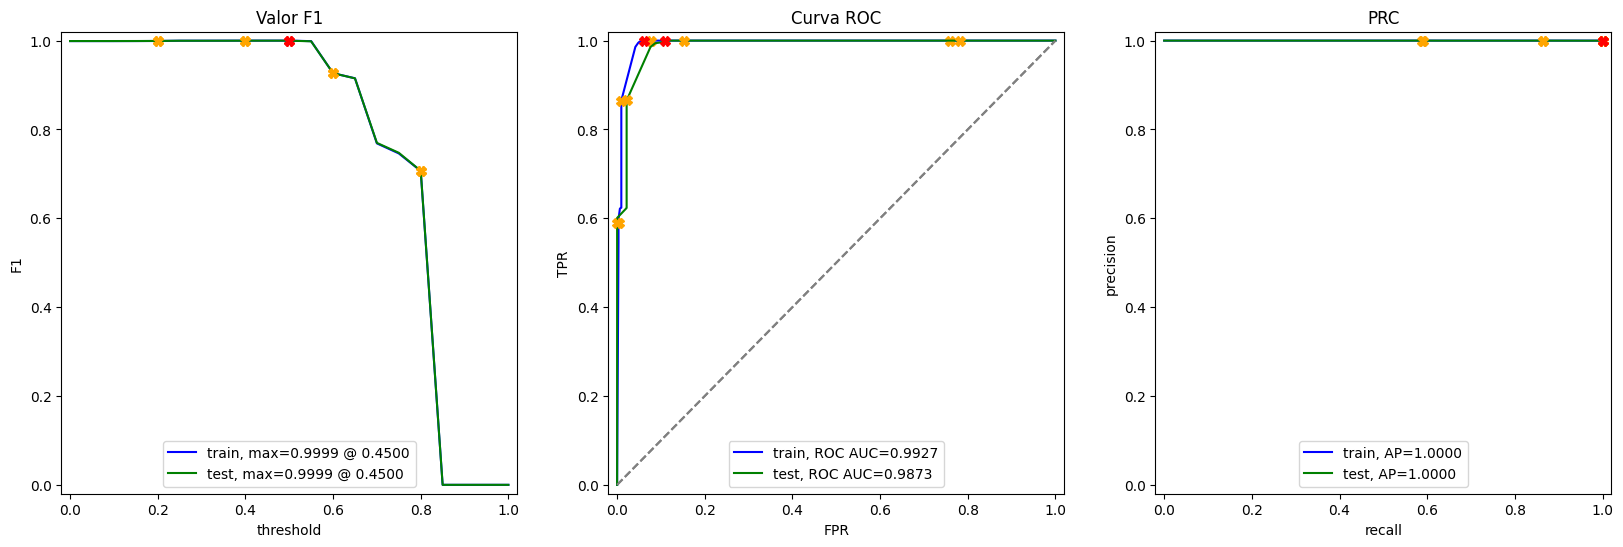

In [62]:
#Bosque aleatorio optimizado
x_train, x_test, y_train, y_test = train_test_split(features3, target3, test_size=0.25, random_state=42) 

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

x_test = scaler.fit_transform(x_test)

Rand_For = RandomForestClassifier(random_state=54321,class_weight='balanced',max_depth = 1, n_estimators = 10,  n_jobs=20)
Rand_For.fit(x_train, y_train)

train_f1, test_f1 = evaluate_model(Rand_For, x_train, y_train, x_test, y_test)

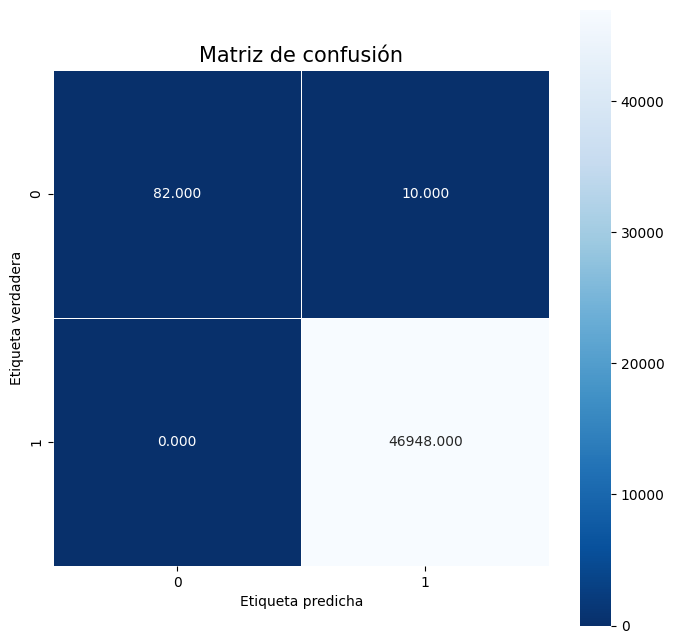

In [63]:
y_pred = Rand_For.predict(x_test)

#Matriz de confusión

cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("MatConfRandomForest.png", format="png")

<div class="alert alert-block alert-info">
<b>

Con el modelo de bosque aleatorio obtenemos una precisión ligeramente menor que el modelo de árboles de decisión, por lo que el aumento en tiempo de cómputo no compensa con el rendimiento del modelo.

De momento sigue siendo preferible el modelo de árboles de decisión.

## Redes neuronales ##

Ahora se prodecerá a hacer el estudio del problema con el uso del modelo de redes neuronales. En particular, se utilizará una red neuronal de Scikit-learn conocida como el Perceptrón Multicapa (MLP).

Accuracy: 0.999546485260771


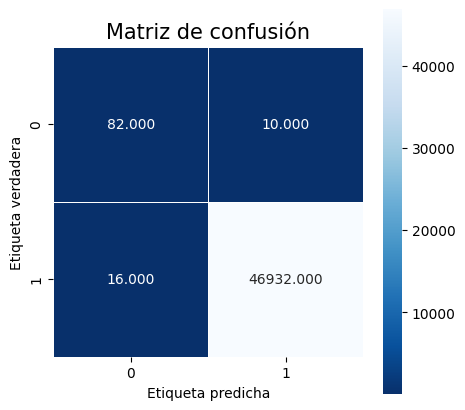

In [64]:
#Separación de nuestra variable objetivo
features4 = dengue_data.drop(columns =['DEFUNCION']) #Base de datos sin las defunciones
target4 = dengue_data['DEFUNCION']                   #Variable objetivo

#------------------------------------------------------------------------------------------------------
#Separación en conjunto de entrenamiento y conjunto de prueba (75% y 25%, respectivamente)

features_train, features_valid, target_train, target_valid = train_test_split(features4, target4, test_size=0.25, random_state=42) 

mlp = MLPClassifier(hidden_layer_sizes=(10,10,10), 
                    activation='relu', 
                    solver='adam', 
                    max_iter=1000)
mlp.fit(features_train,target_train)

predict_train = mlp.predict(features_train)
predict_test = mlp.predict(features_valid)
cm = metrics.confusion_matrix(target_valid,predict_test)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, 
            fmt=".3f", 
            linewidths=.5, 
            square = True, 
            cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)

print("Accuracy:",metrics.accuracy_score(target_train, predict_train))

Ahora, se hace una búsqueda de los mejores parámetros para este modelo.

In [65]:

#param_distributions = {
#    'hidden_layer_sizes': [(10), (10, 10), (20, 20,20)],
#    'alpha': np.logspace(-3, 3, 7),
#    'learning_rate_init': [0.001, 0.01],
#}

#grid = RandomizedSearchCV(
#        estimator  = MLPClassifier(solver = 'lbfgs', max_iter= 1000),
#        param_distributions = param_distributions,
#        n_iter     = 50, # Número máximo de combinaciones probadas
#        scoring    = 'accuracy',
#        n_jobs     = 20,
#        cv         = 3, 
#        verbose    = 0,
#        random_state = 123,
#        return_train_score = True
#       )

#grid.fit(X = features_train, y = target_train)

#modelo = grid.best_estimator_
#modelo

<div> <img src="MLPSearch.png" alt="Drawing" style="width: 635px;"/></div>

<div class="alert alert-block alert-info">
<b>

<ins> IMPORTANTE: </ins> Esta busqueda le tomó 932 segundos al equipo de cómputo que utilicé, por lo que es recomendable solo utilizar los parámetros obtenidos por este o en caso de querer cambiar la cantidad de parámetros a variar, verificar primero la capacidad del equipo de cómputo, ya que esta cuenta está hecha con 20 núcleos.

Por último, se verifica la precisión del modelo utilizando los valores de hiperparámetros obtenidos:

            train    test
Exactitud  0.9999  0.9997
F1         0.9999  0.9999
APS        1.0000  0.9998
ROC AUC    0.9964  0.9839
Accuracy: 0.9998653628117914


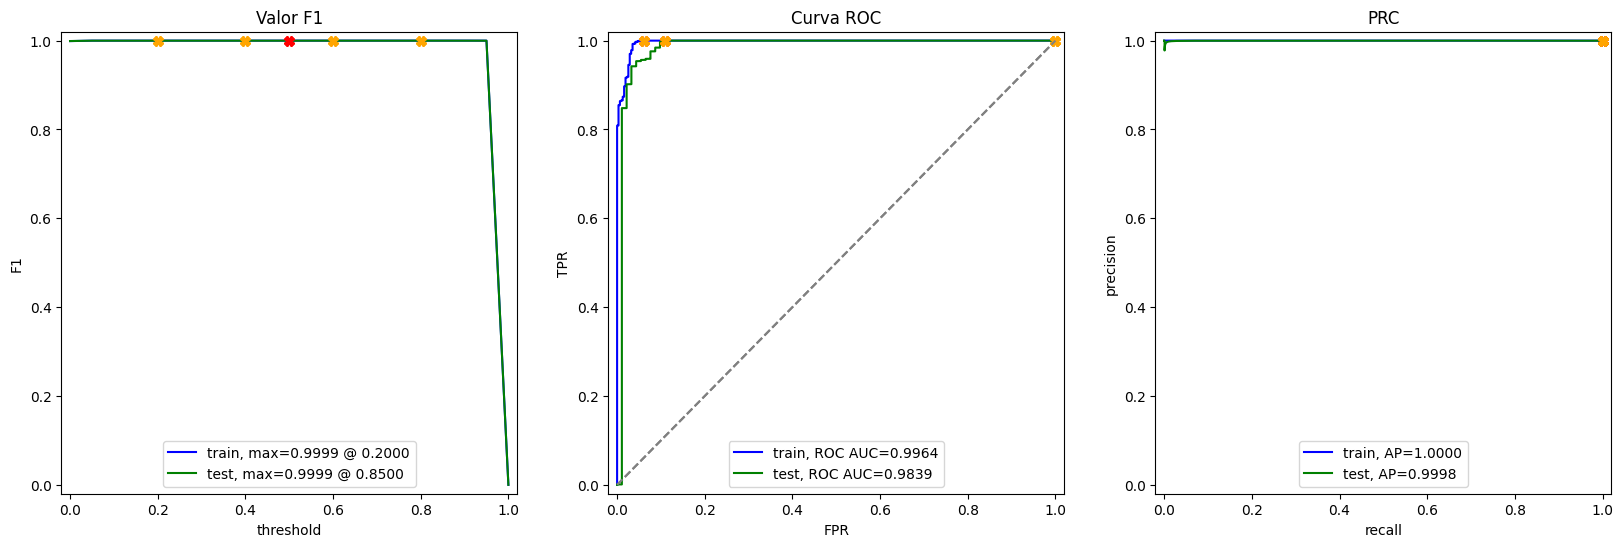

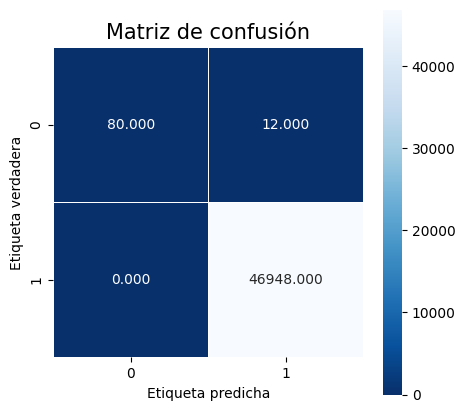

In [66]:
features_train, features_valid, target_train, target_valid = train_test_split(features4, target4, test_size=0.25, random_state=42) 

mlp = MLPClassifier(alpha=0.001,
                    hidden_layer_sizes=(10), 
                    learning_rate_init=0.01,
                    activation='relu', 
                    solver='lbfgs', 
                    max_iter=1000)
mlp.fit(features_train,target_train)

predict_train = mlp.predict(features_train)
predict_test = mlp.predict(features_valid)
cm = metrics.confusion_matrix(target_valid,predict_test)

train_f1, test_f1 = evaluate_model(mlp, features_train, target_train, features_valid, target_valid)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, 
            fmt=".3f", 
            linewidths=.5, 
            square = True, 
            cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("MatConfRedesNeuronales.png", format="png")

print("Accuracy:",metrics.accuracy_score(target_train, predict_train))

<div class="alert alert-block alert-info">
<b>

Con esto podemos notar que el modelo de redes neuronales está por debajo de otros modelos (aunque solo ligeramente), pero este sí requiere un tiempo de cómputo mayor que los demás por lo que será un método que no se utilizará. 

## Estudio y comparación de otros modelos de aprendizaje automatizado (GradientBoosting, LGBM, CatBoost, XGBoost) ##

Entre los últimos modelos que se verificarán están los modelos de ensamble. En particular se analizarán cuatro modelos: Gradient Boosting, Light Gradient Boosting Model (LGBM), CatBoost y XGBoost.

**GradientBoosting**

In [67]:
# Dividir los datos escalados y balaceados en conjuntos de entrenamiento, validación y prueba

train_data, temp_data = train_test_split(dengue_data, test_size=0.4, random_state=12345)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=12345)

train_features = train_data.drop(columns=["DEFUNCION"])
train_target = train_data["DEFUNCION"]

val_features = val_data.drop(columns=["DEFUNCION"])
val_target = val_data["DEFUNCION"]

test_features = test_data.drop(columns=["DEFUNCION"])
test_target = test_data["DEFUNCION"]



Exactitud en el conjunto de prueba: 0.9999468537414966
Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        72
           1       1.00      1.00      1.00     37560

    accuracy                           1.00     37632
   macro avg       1.00      0.99      0.99     37632
weighted avg       1.00      1.00      1.00     37632



Text(0.5, 1.0, 'Matriz de confusión')

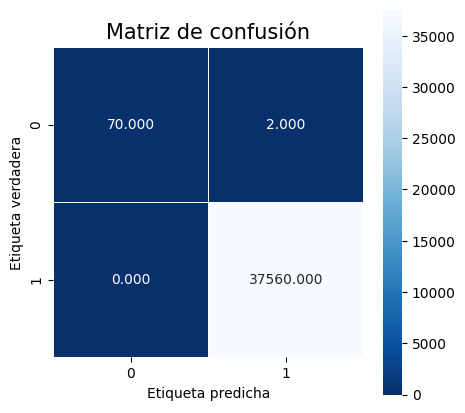

In [68]:
# Crear y entrenar el modelo GradientBoostingClassifier
Grad_Boost = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
Grad_Boost.fit(train_features, train_target)

# Realizar predicciones en el conjunto de prueba
y_pred = Grad_Boost.predict(test_features)

# Evaluar el modelo
accuracy = accuracy_score(test_target, y_pred)
print(f"Exactitud en el conjunto de prueba: {accuracy}")
print("Reporte de clasificación:")
print(classification_report(test_target, y_pred))

cm = metrics.confusion_matrix(test_target,y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, 
            fmt=".3f", 
            linewidths=.5, 
            square = True, 
            cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)

**LGBM**

[LightGBM] [Info] Number of positive: 112646, number of negative: 250
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 112896, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.997786 -> initscore=6.110545
[LightGBM] [Info] Start training from score 6.110545
Exactitud en el conjunto de prueba: 0.9999202806122449
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        72
           1       1.00      1.00      1.00     37560

    accuracy                           1.00     37632
   macro avg       0.99      0.99      0.99     37632
weighted avg       1.00      1.00      1.00     37632



Text(0.5, 1.0, 'Matriz de confusión')

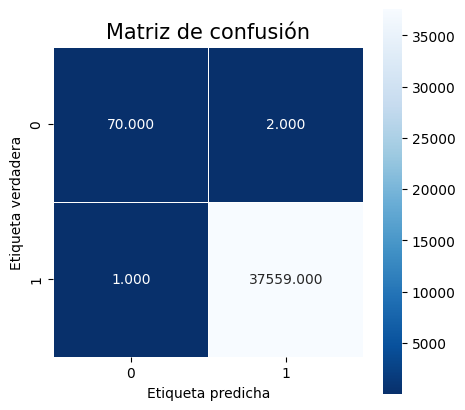

In [69]:
# Crear y entrenar el modelo LGBMClassifier
LGBM = LGBMClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=-1, random_state=42
)
LGBM.fit(train_features, train_target)

# Realizar predicciones en el conjunto de prueba
y_pred = LGBM.predict(test_features)

# Evaluar el modelo
accuracy = accuracy_score(test_target, y_pred)
print(f"Exactitud en el conjunto de prueba: {accuracy}")
print("Reporte de clasificación:")
print(classification_report(test_target, y_pred))

cm = metrics.confusion_matrix(test_target,y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, 
            fmt=".3f", 
            linewidths=.5, 
            square = True, 
            cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)

**CatBoost**

0:	learn: 0.3538119	total: 52.7ms	remaining: 52.6s
100:	learn: 0.0013019	total: 361ms	remaining: 3.22s
200:	learn: 0.0013017	total: 660ms	remaining: 2.62s
300:	learn: 0.0013017	total: 962ms	remaining: 2.23s
400:	learn: 0.0013017	total: 1.26s	remaining: 1.89s
500:	learn: 0.0013017	total: 1.56s	remaining: 1.56s
600:	learn: 0.0013017	total: 1.86s	remaining: 1.24s
700:	learn: 0.0013017	total: 2.16s	remaining: 922ms
800:	learn: 0.0013017	total: 2.46s	remaining: 611ms
900:	learn: 0.0013017	total: 2.76s	remaining: 303ms
999:	learn: 0.0013017	total: 3.05s	remaining: 0us
Exactitud en el conjunto de prueba: 0.9999468537414966
Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        72
           1       1.00      1.00      1.00     37560

    accuracy                           1.00     37632
   macro avg       1.00      0.99      0.99     37632
weighted avg       1.00      1.00      1.00     37632



Text(0.5, 1.0, 'Matriz de confusión')

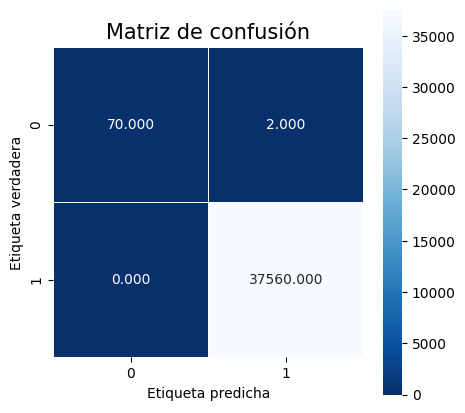

In [70]:
# Crear y entrenar el modelo CatBoostClassifier
Cat_Boost = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
Cat_Boost.fit(train_features, train_target)
# Realizar predicciones en el conjunto de prueba
y_pred = Cat_Boost.predict(test_features)

# Evaluar el modelo
accuracy = accuracy_score(test_target, y_pred)
print(f"Exactitud en el conjunto de prueba: {accuracy}")
print("Reporte de clasificación:")
print(classification_report(test_target, y_pred))

cm = metrics.confusion_matrix(test_target,y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, 
            fmt=".3f", 
            linewidths=.5, 
            square = True, 
            cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)

**XGBoost**

Exactitud en el conjunto de prueba: 0.9999468537414966
Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        72
           1       1.00      1.00      1.00     37560

    accuracy                           1.00     37632
   macro avg       1.00      0.99      0.99     37632
weighted avg       1.00      1.00      1.00     37632



Text(0.5, 1.0, 'Matriz de confusión')

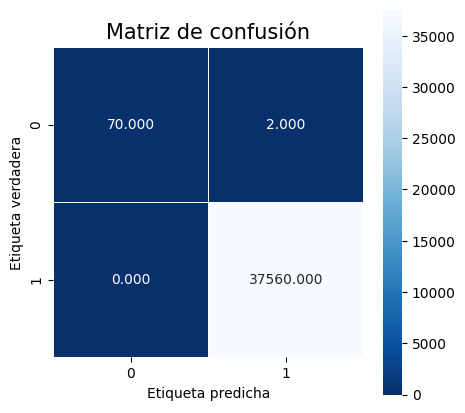

In [71]:
# Crear y entrenar el modelo XGBClassifier

XGB = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
XGB.fit(train_features, train_target)

# Realizar predicciones en el conjunto de prueba
y_pred = XGB.predict(test_features)

# Evaluar el modelo
accuracy = accuracy_score(test_target, y_pred)
print(f"Exactitud en el conjunto de prueba: {accuracy}")
print("Reporte de clasificación:")
print(classification_report(test_target, y_pred))

cm = metrics.confusion_matrix(test_target,y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, 
            fmt=".3f", 
            linewidths=.5, 
            square = True, 
            cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)

<div class="alert alert-block alert-info">
<b>

Aquí vemos como estos métodos que utilizan una combinación de distintos modelos sí aumentan la precisión de nuestro problema. Ahora solo falta averiguar si su tiempo de cómputo no es un problema a la hora de hacer las predicciones.

In [72]:
# Definir los modelos y sus nombres
models = [
    LogisticRegression(random_state=12345),
    DecisionTreeClassifier(random_state=12345),
    RandomForestClassifier(random_state=12345),
    GradientBoostingClassifier(random_state=12345),
    LGBMClassifier(random_state=12345, force_row_wise=True),
    CatBoostClassifier(random_state=12345),
    xgb.XGBClassifier(random_state=12345),
]

model_names = [
    "Logistic Regression",
    "DecisionTree",
    "Random Forest",
    "Gradient Boosting",
    "LGBM",
    "CatBoost",
    "XGBoost",
]

In [73]:
def train_and_evaluate_models(
    train_features,
    train_target,
    val_features,
    val_target,
    test_features,
    test_target,
    models,
    model_names
):
    """
    Entrenar y evaluar varios modelos de aprendizaje automático

    train_features: Características de entrenamiento
    train_target: Variable objetivo de entrenamiento
    val_features: Características de validación
    val_target: Variable objetivo de validación
    test_features: Características de prueba
    test_target: Variable objetivo de prueba
    models: Lista de modelos de aprendizaje automático
    model_names: Lista de nombres de modelos

    1. Iterar sobre los modelos y sus nombres
    2. Entrenar cada modelo
    3. Evaluar cada modelo en los conjuntos de entrenamiento,
    validación y prueba
    4. Imprimir las métricas F1 y AUC para cada modelo y conjunto
    5. Devolver las métricas F1 y AUC para cada modelo y conjunto
    """
    f1_scores = []
    roc_auc_scores = []
    time_scores = []
    parameters = []

    for model, model_name in zip(models, model_names):
        print(f"\n{model_name}")
        start_time = time()
        model.fit(train_features, train_target)

        # Guardar hiperparametrsos
        parameters.append((model_name, model.get_params()))
        print(model.get_params())

        # Evaluar el modelo en el conjunto de entrenamiento
        train_predictions = model.predict(train_features)
        f1_train = f1_score(train_target, train_predictions, average="weighted")
        auc_train = roc_auc_score(train_target, train_predictions)

        # Evaluar el modelo en el conjunto de validación
        val_predictions = model.predict(val_features)
        f1_val = f1_score(val_target, val_predictions, average="weighted")
        auc_val = roc_auc_score(val_target, val_predictions)

        # Evaluar el modelo en el conjunto de prueba
        test_predictions = model.predict(test_features)
        f1_test = f1_score(test_target, test_predictions, average="weighted")
        auc_test = roc_auc_score(test_target, test_predictions)

        # Almacenar las métricas
        f1_scores.append((model_name, f1_train, f1_val, f1_test))
        roc_auc_scores.append((model_name, auc_train, auc_val, auc_test))
        end_time = time()
        time_scores.append((model_name, end_time - start_time))

        # Imprimir las métricas
        print(f"Train: F1 {f1_train}, AUC {auc_train}")
        print(f"Validation: F1 {f1_val}, AUC {auc_val}")
        print(f"Test: F1 {f1_test}, AUC {auc_test}")
        print(f"Time: {end_time - start_time} seconds")

    return f1_scores, roc_auc_scores, time_scores, parameters

In [74]:
# Llamar a la función
f1_scores, roc_auc_scores, time_scores, parameters = train_and_evaluate_models(
    train_features,
    train_target,
    val_features,
    val_target,
    test_features,
    test_target,
    models,
    model_names
)


Logistic Regression
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 12345, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Train: F1 0.9997727421006768, AUC 0.9500000000000001
Validation: F1 0.9995813792555928, AUC 0.9085365853658537
Test: F1 0.9998921918482531, AUC 0.9722222222222222
Time: 0.2232515811920166 seconds

DecisionTree
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 12345, 'splitter': 'best'}
Train: F1 0.9999467472579994, AUC 0.991991122631962
Validation: F1 0.9994469654362508, AUC 0.9449621642687798
Test: F1 0.9997648465978609, AUC 0.9860179268725595
Time: 0.147034406661

In [75]:
def plot_and_print_scores(models, model_names, f1_scores, roc_auc_scores, time_scores):
    """
    Graficar y mostrar los puntajes F1, AUC y el tiempo de ejecución de los modelos

    models: Lista de modelos de aprendizaje automático
    model_names: Lista de nombres de modelos
    f1_scores: Lista de tuplas con puntajes F1
    roc_auc_scores: Lista de tuplas con puntajes AUC
    time_scores: Lista de tuplas con tiempos de ejecución

    1. Crear DataFrames para los puntajes F1, AUC y tiempos de ejecución
    2. Derretir los DataFrames para facilitar la visualización
    3. Graficar los puntajes F1
    4. Graficar los puntajes AUC
    5. Graficar los tiempos de ejecución
    6. Imprimir los resultados

    """
    # Crear DataFrames para los F1 scores, ROC AUC scores y tiempos de ejecución
    f1_scores_df = pd.DataFrame(
        f1_scores, columns=["Model", "F1 Train", "F1 Validation", "F1 Test"]
    )
    roc_auc_scores_df = pd.DataFrame(
        roc_auc_scores, columns=["Model", "AUC Train", "AUC Validation", "AUC Test"]
    )
    time_scores_df = pd.DataFrame(time_scores, columns=["Model", "Time"])

    # Derretir los DataFrames para que sean más fáciles de graficar
    f1_scores_melted = f1_scores_df.melt(
        id_vars="Model", var_name="Dataset", value_name="F1 Score"
    )
    roc_auc_scores_melted = roc_auc_scores_df.melt(
        id_vars="Model", var_name="Dataset", value_name="AUC Score"
    )

    # Graficar los F1 scores
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Model", y="F1 Score", hue="Dataset", data=f1_scores_melted)
    plt.title("F1 Scores for Train, Validation, and Test Sets")
    plt.ylabel("F1 Score")
    plt.xlabel("Model")
    plt.legend(title="Dataset")
    plt.xticks(rotation=45)
    plt.ylim(0, 1.2)
    plt.savefig("F1Score.png", format="png")
    plt.show()

    # Graficar los ROC AUC scores
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Model", y="AUC Score", hue="Dataset", data=roc_auc_scores_melted)
    plt.title("ROC AUC Scores for Train, Validation, and Test Sets")
    plt.ylabel("AUC Score")
    plt.xlabel("Model")
    plt.legend(title="Dataset")
    plt.xticks(rotation=45)
    plt.ylim(0, 1.2)
    plt.savefig("ROC_AUC.png", format="png")
    plt.show()

    # Graficar los tiempos de ejecución
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Model", y="Time", data=time_scores_df)
    plt.title("Execution Time for Each Model")
    plt.ylabel("Time (seconds)")
    plt.xlabel("Model")
    plt.xticks(rotation=45)
    plt.savefig("TiempoEjecución.png", format="png")
    plt.show()

    # F1
    f1_scores_df = f1_scores_df.sort_values(by="F1 Test", ascending=False)
    print("Resultados de F1 de los Modelos:")
    print(f1_scores_df)

    # auc
    roc_auc_scores_df = roc_auc_scores_df.sort_values(by="AUC Test", ascending=False)
    print("Resultados de AUC de los Modelos:")
    print(roc_auc_scores_df)

    # time
    time_scores_df = time_scores_df.sort_values(by="Time", ascending=True)
    print("Tiempo de ejecución de los Modelos:")
    print(time_scores_df)

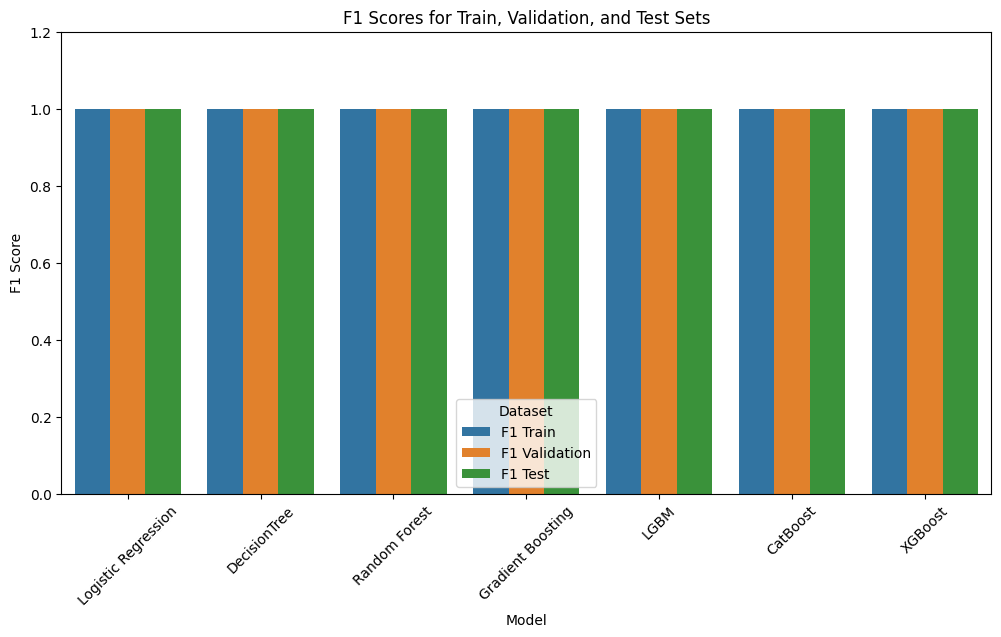

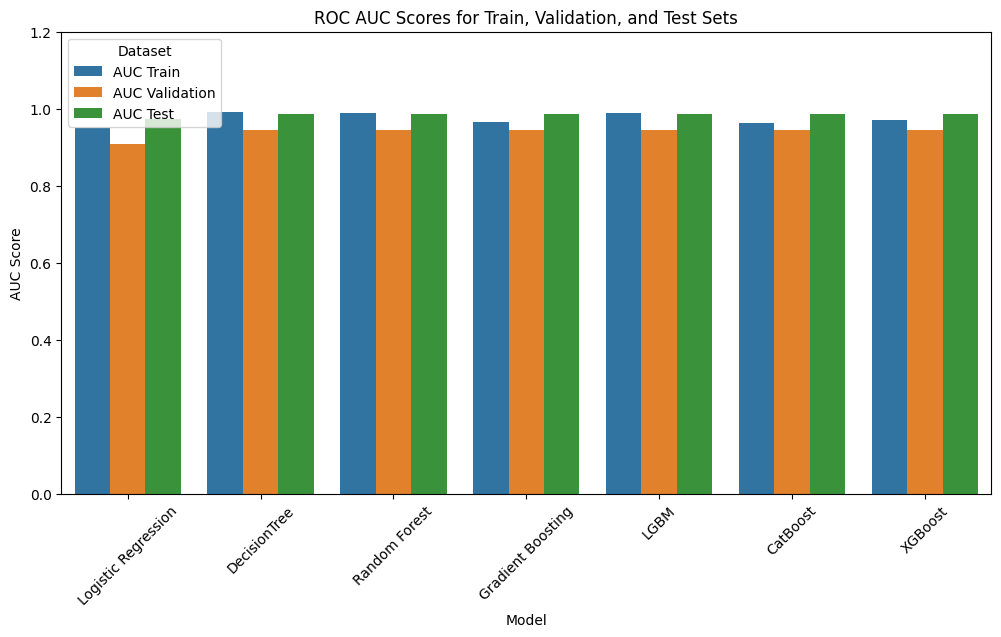

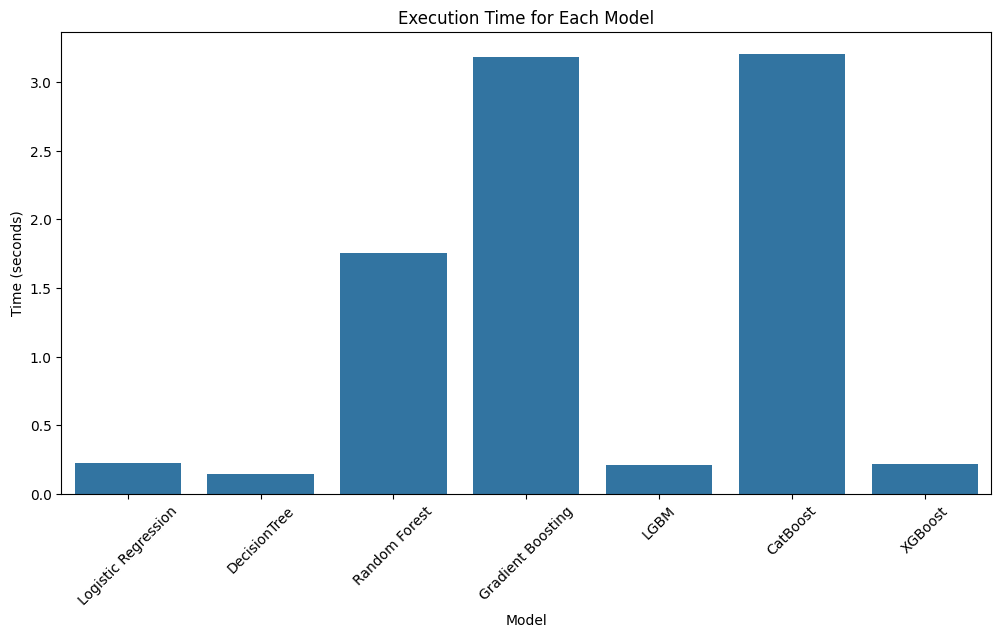

Resultados de F1 de los Modelos:
                 Model  F1 Train  F1 Validation   F1 Test
3    Gradient Boosting  0.999847       0.999675  0.999946
5             CatBoost  0.999838       0.999754  0.999946
2        Random Forest  0.999947       0.999727  0.999920
4                 LGBM  0.999947       0.999727  0.999920
6              XGBoost  0.999874       0.999727  0.999920
0  Logistic Regression  0.999773       0.999581  0.999892
1         DecisionTree  0.999947       0.999447  0.999765
Resultados de AUC de los Modelos:
                 Model  AUC Train  AUC Validation  AUC Test
3    Gradient Boosting   0.966000        0.945082  0.986111
5             CatBoost   0.964000        0.945122  0.986111
2        Random Forest   0.988000        0.945109  0.986098
4                 LGBM   0.988000        0.945109  0.986098
6              XGBoost   0.972000        0.945109  0.986098
1         DecisionTree   0.991991        0.944962  0.986018
0  Logistic Regression   0.950000        0.908537

In [76]:
plot_and_print_scores(models, model_names, f1_scores, roc_auc_scores, time_scores)

<div class="alert alert-block alert-info">
<b>

Podemos concluir que en precisión el mejor modelo es el Gradient Boosting, mientras que el que mejor tiempo de cómputo tiene es el Árboles de decisión. Pero al ser un tiempo de cómputo aceptable para nuestros cálculos, se primará la precisión y el modelo elegido para el estudio será el de Gradient Boosting.



## Precisión del modelo elegido ##

Debido a que los datos usados son del 01/01/2024 al 02/09/2024, y como el gobierno de México actualiza semanalmente sus registros, se pueden utilizar los datos del 02/09/2024 al 09/12/2024.

In [77]:
#Base de datos 

dengue_data2 = pd.read_csv("dengue_abierto.csv")    
dengue_data2["ID_REGISTRO"]
ID_Max = dengue_data2['ID_REGISTRO'].max()

dengue_data3 = pd.read_csv("dengue_abierto_Dic.csv") #Base de datos actualizada al 09/12/2024

dengue_data_Dic = dengue_data3[dengue_data3['ID_REGISTRO'] > ID_Max].copy() #Datos de 02/09/2024 al 09/12/2024

#Primera eliminación de variables
dengue_data_Dic.drop(columns=['FECHA_ACTUALIZACION','ID_REGISTRO','MUNICIPIO_RES','MUNICIPIO_UM_NOTIF','MUNICIPIO_ASIG', "FECHA_SIGN_SINTOMAS"],inplace=True) 

#Eliminación de datos con pacientes negativos

dengue_data_Dic.drop(dengue_data_Dic.loc[dengue_data_Dic['ESTATUS_CASO'] == 3].index,inplace=True)

#Segunda eliminación de variables
dengue_data_Dic.drop(columns=['ENTIDAD_UM_NOTIF','ENTIDAD_ASIG','HABLA_LENGUA_INDIG'],inplace=True) 

#Cambio de variables para facilidad de manejo

dengue_data_Dic['DEFUNCION'] = dengue_data_Dic['DEFUNCION'].replace(1, 0)
dengue_data_Dic['DEFUNCION'] = dengue_data_Dic['DEFUNCION'].replace(2, 1)

dengue_data_Dic

,SEXO,EDAD_ANOS,ENTIDAD_RES,INDIGENA,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,HIPERTENSION,ENFERMEDAD_ULC_PEPTICA,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO
139337,1,23,7,2,20,1,2,2,2,2,2,2,2,2,1,5.0,1,5,2
139998,2,43,19,2,4,1,2,1,2,2,2,2,2,2,1,5.0,1,3,2
139999,2,72,16,2,6,1,2,2,2,2,2,2,2,2,1,5.0,2,5,1
140000,1,30,28,2,20,1,2,2,2,2,2,2,2,2,1,5.0,2,5,1
140001,1,19,27,2,4,1,2,2,2,2,2,2,2,2,1,5.0,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542745,1,35,14,2,12,1,2,2,2,2,2,2,2,2,1,5.0,1,5,1
542746,1,33,5,2,6,1,2,2,2,2,2,2,2,2,1,5.0,2,5,1
542747,2,14,16,2,20,1,2,2,2,2,2,2,2,2,1,5.0,1,5,1
542748,2,5,7,2,6,2,2,2,2,2,2,2,2,2,1,5.0,1,5,2


In [78]:
dengue_data

,SEXO,EDAD_ANOS,ENTIDAD_RES,INDIGENA,INSTITUCION_UM_NOTIF,TIPO_PACIENTE,HEMORRAGICOS,DIABETES,HIPERTENSION,ENFERMEDAD_ULC_PEPTICA,ENFERMEDAD_RENAL,INMUNOSUPR,CIRROSIS_HEPATICA,EMBARAZO,DEFUNCION,DICTAMEN,TOMA_MUESTRA,RESULTADO_PCR,ESTATUS_CASO
1,2,55,18,2,4,1,2,2,2,2,2,2,2,2,1,5.0,2,5,1
2,2,11,20,2,20,1,2,2,2,2,2,2,2,2,1,5.0,2,5,1
3,1,51,17,2,4,1,2,2,2,2,2,2,2,2,1,5.0,1,5,1
5,2,3,27,2,20,1,2,2,2,2,2,2,2,2,1,5.0,2,5,1
6,1,23,20,2,4,1,2,2,2,2,2,2,2,2,1,5.0,2,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237591,2,34,17,2,4,1,2,2,2,2,2,2,2,2,1,5.0,1,5,1
237592,1,21,17,2,4,1,2,2,2,2,2,2,2,2,1,5.0,1,5,1
237593,2,3,7,2,20,2,2,2,2,2,2,2,2,2,1,5.0,1,5,1
237594,1,19,15,2,20,2,2,2,2,2,2,2,2,2,1,5.0,1,5,1


Dado que la base de datos es tan grande, se utilizará la primera para entrenar el modelo y las mitades de esta para la validación y la prueba. 

In [79]:
# Dividir los datos escalados y balaceados en conjuntos de entrenamiento, validación y prueba

train_data = dengue_data
val_data, test_data = train_test_split(dengue_data_Dic, test_size=0.5, random_state=12345)

train_features = train_data.drop(columns=["DEFUNCION"])
train_target = train_data["DEFUNCION"]

val_features = val_data.drop(columns=["DEFUNCION"])
val_target = val_data["DEFUNCION"]

test_features = test_data.drop(columns=["DEFUNCION"])
test_target = test_data["DEFUNCION"]


Exactitud en el conjunto de prueba: 0.9999324653885117
Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       324
           1       1.00      1.00      1.00    132941

    accuracy                           1.00    133265
   macro avg       1.00      0.99      0.99    133265
weighted avg       1.00      1.00      1.00    133265

            train    test
Exactitud  0.9999  0.9999
F1         0.9999  1.0000
APS        1.0000  1.0000
ROC AUC    0.9991  0.9991


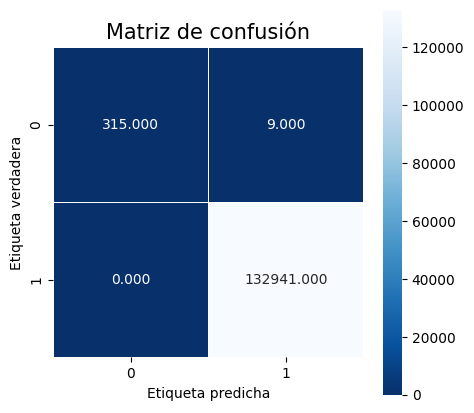

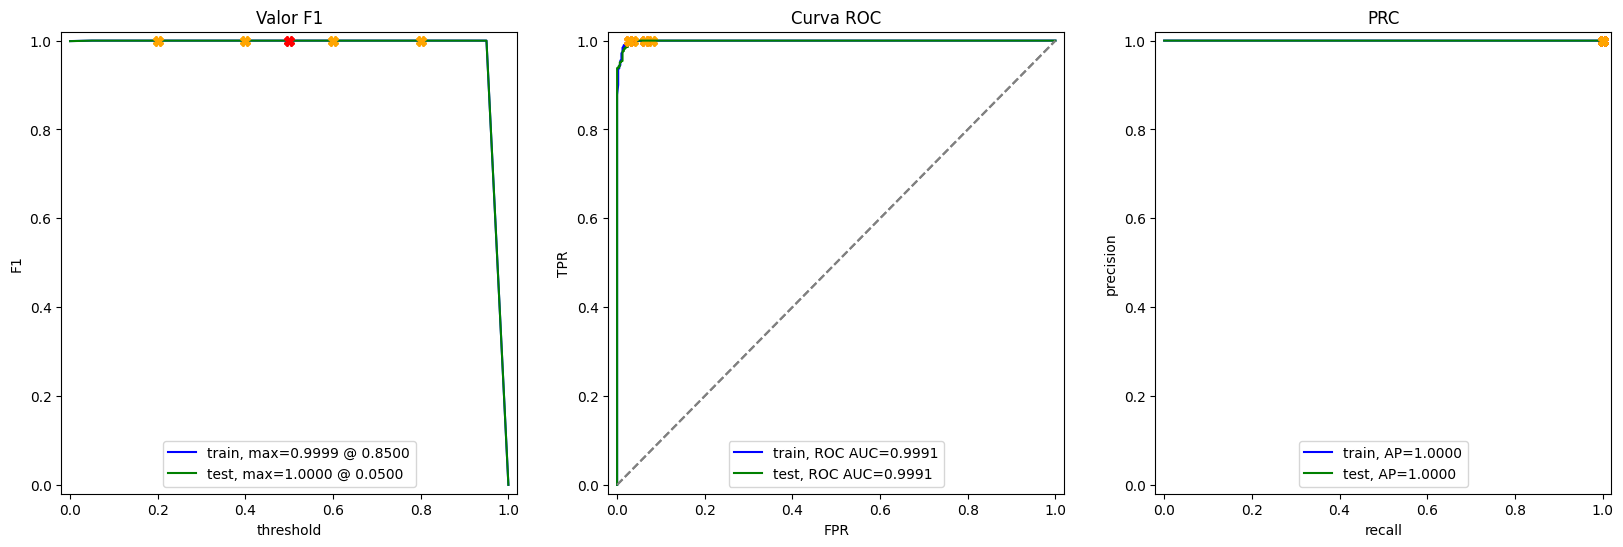

In [80]:
# Crear y entrenar el modelo GradientBoostingClassifier
Grad_Boost = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
Grad_Boost.fit(train_features, train_target)

# Realizar predicciones en el conjunto de prueba
y_pred = Grad_Boost.predict(test_features)

# Evaluar el modelo
accuracy = accuracy_score(test_target, y_pred)
print(f"Exactitud en el conjunto de prueba: {accuracy}")
print("Reporte de clasificación:")
print(classification_report(test_target, y_pred))

cm = metrics.confusion_matrix(test_target,y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, 
            fmt=".3f", 
            linewidths=.5, 
            square = True, 
            cmap = 'Blues_r')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusión', size = 15)
plt.savefig("ConfMat_ModeloElegido.png", format="png")

train_f1, test_f1 = evaluate_model(Grad_Boost, train_features, train_target, test_features, test_target)

<div class="alert alert-block alert-info">
<b>

Finalizamos el estudio de este proyecto con un modelo de Gradient Boost cuya precisión es de 0.99993 y que solo clasificó incorrectamente 9 pacientes de 133 265. Esto nos permite tener gran certeza en nuestra predicción de la supervivencia de un paciente contagiado de dengue/chikungunya. 